# 항공 승객 만족도 이진분류 및 승객 군집 분석

## 프로젝트 정보

- 주제: 승객 만족도 예측
- 과제: 서비스 평점, 지연시간 및 승객 특성을 이용하여 승객의 만족 여부를 예측한다.
- 데이터 출처: [Kaggle - Airline Passenger Satisfaction](https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction)
- 데이터 제공자: TJ Klein(teejmahal20)
- 라이선스: Other (specified in description)

## 문제 정의

본 프로젝트는 승객 특성과 항공 서비스 평가를 이용하여 승객의 만족 여부를 예측하는 이진분류 문제이다.

- 양성 클래스(1): satisfied
- 음성 클래스(0): neutral or dissatisfied
- 비즈니스 목적: 불만족 가능성이 높은 승객과 개선 우선 서비스 요인을 파악하여 고객 경험 개선에 활용한다.
- 성공 기준: 실제 불만족 고객을 만족으로 잘못 분류하는 FP의 비용이
  크다고 판단하여 Precision과 FPR을 핵심 지표로 사용한다.
  F1-score와 Recall도 함께 확인하여 FP 감소로 인해 FN이 지나치게
  증가하지 않는지 평가한다.
- 임계값 선택 기준: validation 데이터에서 Precision 0.99 이상,
  Recall 0.91 이상, F1-score 0.95 이상을 유지하는 범위에서 FP가
  가장 적은 임계값을 선택한다. test 데이터는 최종 평가에만 사용한다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

print(train.shape)
print(test.shape)

train.head()

(103904, 25)
(25976, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [2]:
print(train.info())

<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  str    
 3   Customer Type                      103904 non-null  str    
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  str    
 6   Class                              103904 non-null  str    
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      103904 non-null

In [3]:
print(test.info())

<class 'pandas.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         25976 non-null  int64  
 1   id                                 25976 non-null  int64  
 2   Gender                             25976 non-null  str    
 3   Customer Type                      25976 non-null  str    
 4   Age                                25976 non-null  int64  
 5   Type of Travel                     25976 non-null  str    
 6   Class                              25976 non-null  str    
 7   Flight Distance                    25976 non-null  int64  
 8   Inflight wifi service              25976 non-null  int64  
 9   Departure/Arrival time convenient  25976 non-null  int64  
 10  Ease of Online booking             25976 non-null  int64  
 11  Gate location                      25976 non-null  int64  
 12  F

In [4]:
print(train.isnull().sum()) # 결측치 확인

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction    

## 탐색적 데이터 분석(EDA): 만족도와 주요 변수의 관계

아래 시각화는 `train` 데이터만 사용한다. `test` 데이터는 최종 모델 평가 전까지 탐색과 모델 선택에 사용하지 않는다.


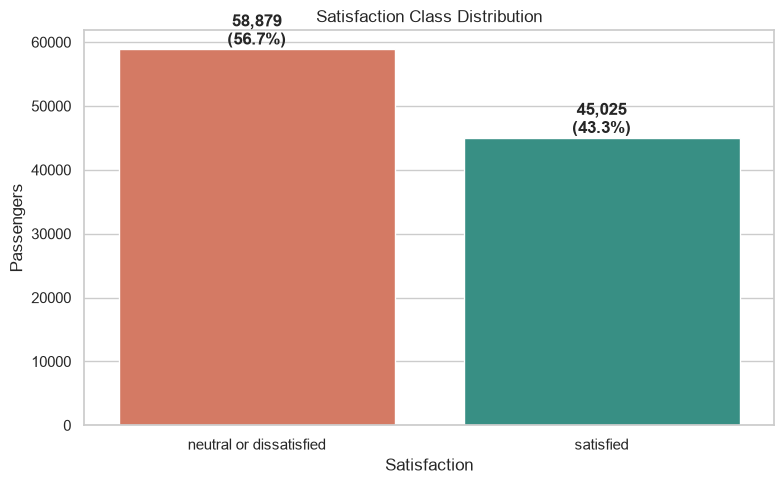

In [5]:
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
SAT_ORDER = ["neutral or dissatisfied", "satisfied"]
SAT_COLORS = ["#E76F51", "#2A9D8F"]

# 1. 타깃 클래스 분포
fig, ax = plt.subplots(figsize=(8, 5))
counts = train["satisfaction"].value_counts().reindex(SAT_ORDER)
sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
            palette=SAT_COLORS, legend=False, ax=ax)
for i, value in enumerate(counts.values):
    ax.text(i, value, f"{value:,}\n({value / len(train):.1%})",
            ha="center", va="bottom", fontweight="bold")
ax.set(title="Satisfaction Class Distribution", xlabel="Satisfaction", ylabel="Passengers")
plt.tight_layout()
plt.show()


### 범주형 변수별 만족률

여행 목적, 좌석 등급, 고객 유형별로 `satisfied` 비율을 비교한다. 성별은 집단 차이가 작아 보조 분석으로 남긴다.


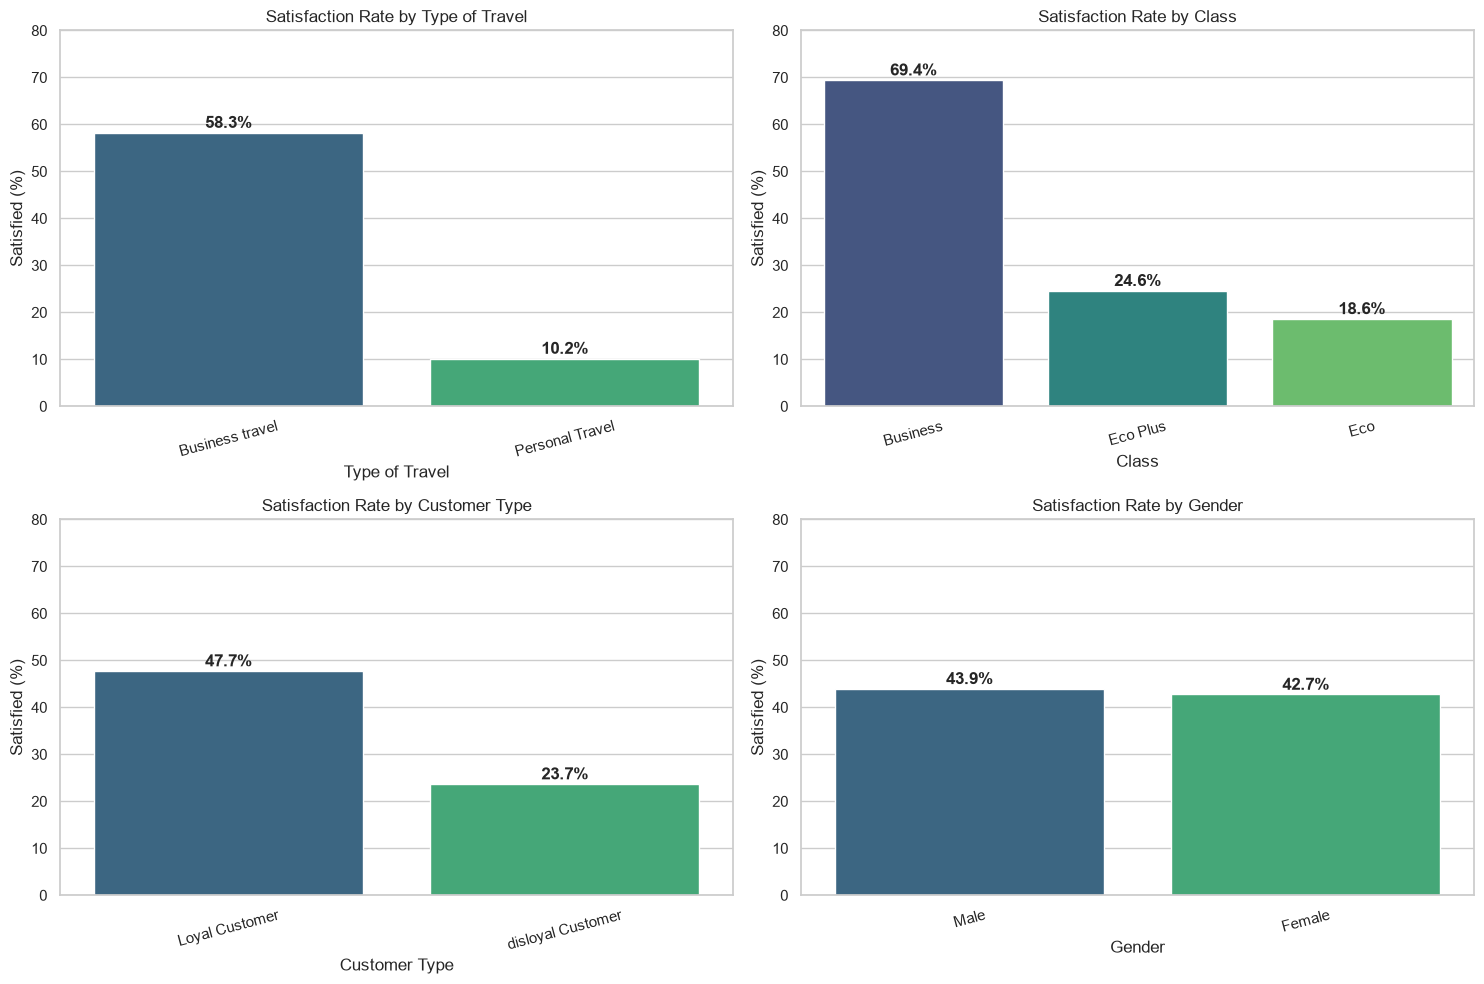

In [6]:
# 2. 주요 범주형 변수별 만족률
categorical_features = ["Type of Travel", "Class", "Customer Type", "Gender"]
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, feature in zip(axes.flat, categorical_features):
    rate = (train.assign(is_satisfied=train["satisfaction"].eq("satisfied"))
                 .groupby(feature, observed=False)["is_satisfied"]
                 .mean().mul(100).sort_values(ascending=False))
    sns.barplot(x=rate.index, y=rate.values, hue=rate.index,
                palette="viridis", legend=False, ax=ax)
    for i, value in enumerate(rate.values):
        ax.text(i, value + 1, f"{value:.1f}%", ha="center", fontweight="bold")
    ax.set(title=f"Satisfaction Rate by {feature}", xlabel=feature,
           ylabel="Satisfied (%)", ylim=(0, 80))
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


### 서비스 항목별 만족·불만족 평균 비교

두 클래스의 평균 점수 차이가 클수록 만족도를 구분하는 후보 변수로 볼 수 있다. 이는 인과관계가 아니라 단순 집단 차이다.


In [7]:
# 3번 이후 그래프의 한글 표시 설정
import matplotlib.font_manager as fm

font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False

# 그래프 표시용 한글 변수명
column_korean = {
    "Inflight wifi service": "기내 와이파이 서비스",
    "Departure/Arrival time convenient": "출발·도착 시간 편의성",
    "Ease of Online booking": "온라인 예약 편의성",
    "Gate location": "탑승구 위치",
    "Food and drink": "음식 및 음료",
    "Online boarding": "온라인 탑승",
    "Seat comfort": "좌석 편안함",
    "Inflight entertainment": "기내 엔터테인먼트",
    "On-board service": "기내 서비스",
    "Leg room service": "다리 공간 서비스",
    "Baggage handling": "수하물 처리",
    "Checkin service": "체크인 서비스",
    "Inflight service": "기내 지원 서비스",
    "Cleanliness": "청결도",
    "Flight Distance": "비행 거리",
    "Age": "나이",
    "Arrival Delay in Minutes": "도착 지연시간(분)",
    "Departure Delay in Minutes": "출발 지연시간(분)"
}

print("3번 이후 그래프 적용 폰트:", font_name)

3번 이후 그래프 적용 폰트: Malgun Gothic


In [8]:
# 3. 만족/불만족 집단의 서비스 평가 평균
service_features = [
    "Inflight wifi service", "Departure/Arrival time convenient",
    "Ease of Online booking", "Gate location", "Food and drink",
    "Online boarding", "Seat comfort", "Inflight entertainment",
    "On-board service", "Leg room service", "Baggage handling",
    "Checkin service", "Inflight service", "Cleanliness"
]

service_means = (train.groupby("satisfaction")[service_features]
                      .mean().T.reindex(columns=SAT_ORDER))
service_means["difference"] = (
    service_means["satisfied"] - service_means["neutral or dissatisfied"]
)
service_means = service_means.sort_values("difference")


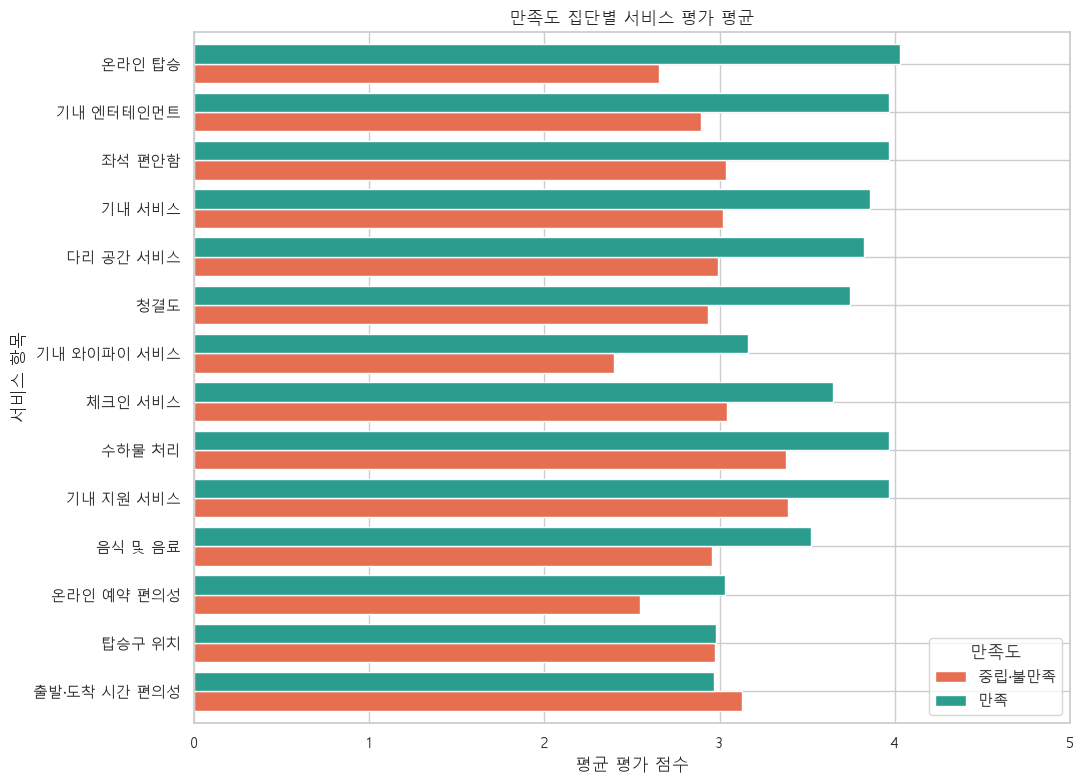

satisfaction,neutral or dissatisfied,satisfied,difference
온라인 탑승,2.66,4.03,1.37
기내 엔터테인먼트,2.89,3.96,1.07
좌석 편안함,3.04,3.97,0.93
기내 서비스,3.02,3.86,0.84
다리 공간 서비스,2.99,3.82,0.83
청결도,2.94,3.74,0.81
기내 와이파이 서비스,2.40,3.16,0.76
체크인 서비스,3.04,3.65,0.60
수하물 처리,3.38,3.97,0.59
기내 지원 서비스,3.39,3.97,0.58


In [9]:
# 그래프용 복사본에만 한국어 변수명 적용
service_means_korean = service_means.rename(
    index=column_korean
)

ax = service_means_korean[SAT_ORDER].plot(
    kind="barh",
    figsize=(11, 8),
    color=SAT_COLORS,
    width=0.8
)

ax.set(
    title="만족도 집단별 서비스 평가 평균",
    xlabel="평균 평가 점수",
    ylabel="서비스 항목",
    xlim=(0, 5)
)

ax.legend(
    labels=["중립·불만족", "만족"],
    title="만족도",
    loc="lower right"
)

plt.tight_layout()
plt.show()

# 결과표
display(
    service_means_korean
    .sort_values("difference", ascending=False)
    .round(2)
)

### 수치형 변수와 만족도의 상관관계

타깃을 `satisfied=1`, `neutral or dissatisfied=0`으로 임시 변환하여 피어슨 상관계수를 계산한다. 식별자인 `id`와 `Unnamed: 0`은 제외한다.


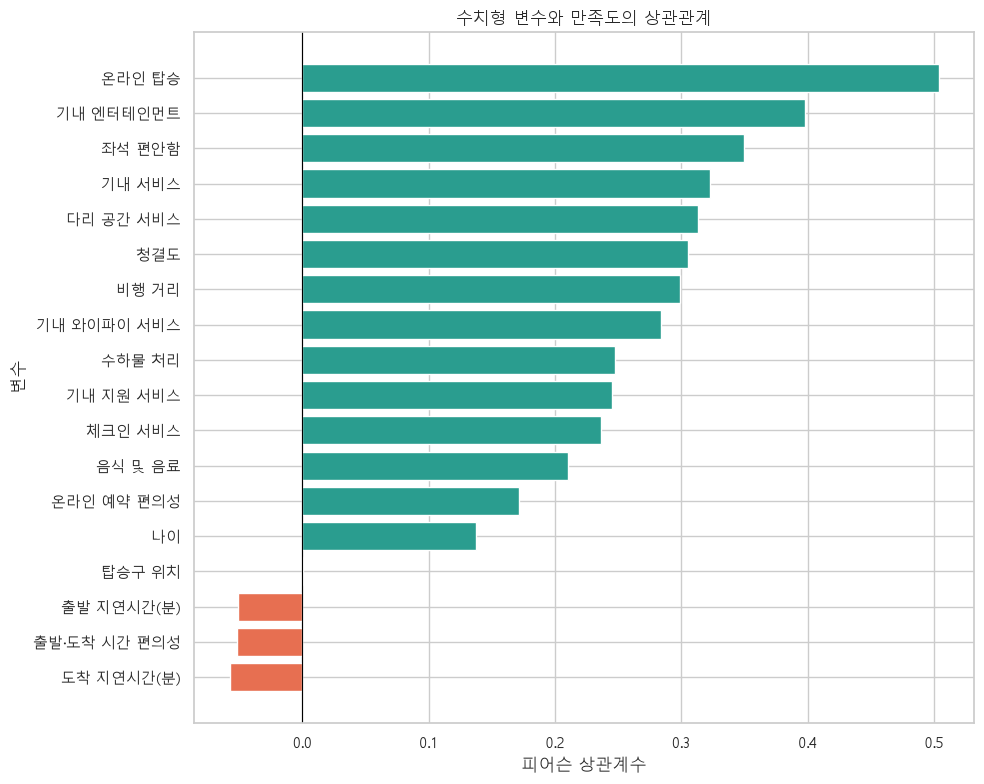

,correlation
온라인 탑승,0.504
기내 엔터테인먼트,0.398
좌석 편안함,0.349
기내 서비스,0.322
다리 공간 서비스,0.313
청결도,0.305
비행 거리,0.299
기내 와이파이 서비스,0.284
수하물 처리,0.248
기내 지원 서비스,0.245


In [10]:
# 4. 만족도와 수치형 변수의 상관관계
eda_numeric = train.select_dtypes(include="number").drop(
    columns=["Unnamed: 0", "id"], errors="ignore"
).copy()
eda_numeric["satisfaction_flag"] = train["satisfaction"].eq("satisfied").astype(int)

target_corr = (eda_numeric.corr()["satisfaction_flag"]
               .drop("satisfaction_flag")
               .sort_values())
# 그래프용 데이터 한국어 이름 적용
target_corr_korean = target_corr.rename(
    index=column_korean
)

fig, ax = plt.subplots(figsize=(10, 8))

colors = [
    "#E76F51" if value < 0 else "#2A9D8F"
    for value in target_corr_korean.values
]

ax.barh(
    target_corr_korean.index,
    target_corr_korean.values,
    color=colors
)

ax.axvline(
    0,
    color="black",
    linewidth=0.8
)

ax.set(
    title="수치형 변수와 만족도의 상관관계",
    xlabel="피어슨 상관계수",
    ylabel="변수"
)

plt.tight_layout()
plt.show()

# 결과표
display(
    target_corr_korean
    .sort_values(key=abs, ascending=False)
    .to_frame("correlation")
    .round(3)
)


### 출발·도착 지연과 만족도

지연시간은 극단값이 많으므로 시각화에서만 상위 1%를 잘라 분포를 비교한다. 원본 데이터의 이상치를 삭제하는 것은 아니다.


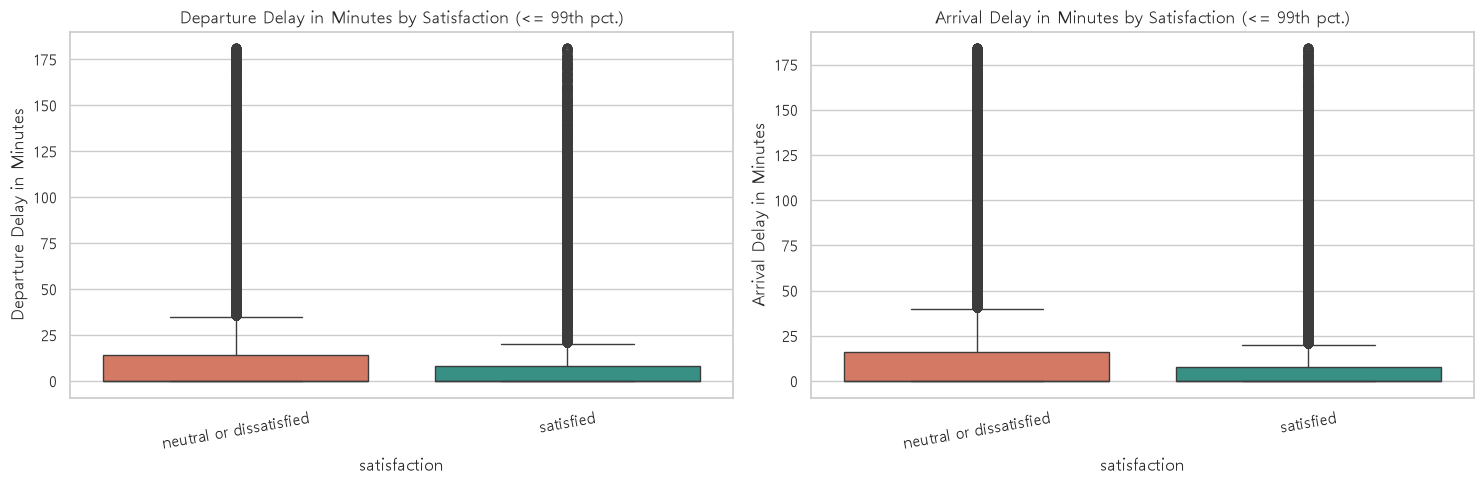

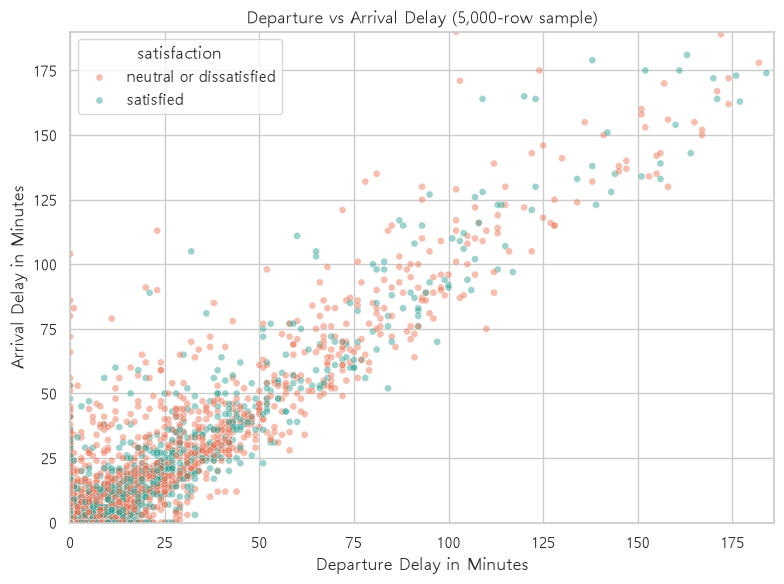

Departure–arrival delay correlation: 0.9655


In [11]:
# 5. 지연시간 분포와 출발-도착 지연 관계
delay_cols = ["Departure Delay in Minutes", "Arrival Delay in Minutes"]
plot_data = train[[*delay_cols, "satisfaction"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, feature in zip(axes, delay_cols):
    upper = plot_data[feature].quantile(0.99)
    sns.boxplot(data=plot_data[plot_data[feature] <= upper],
                x="satisfaction", y=feature, order=SAT_ORDER,
                hue="satisfaction", palette=SAT_COLORS, legend=False, ax=ax)
    ax.set_title(f"{feature} by Satisfaction (<= 99th pct.)")
    ax.tick_params(axis="x", rotation=10)
plt.tight_layout()
plt.show()

sample = plot_data.dropna().sample(n=min(5000, plot_data.dropna().shape[0]), random_state=10)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=sample, x="Departure Delay in Minutes",
                y="Arrival Delay in Minutes", hue="satisfaction",
                hue_order=SAT_ORDER, palette=SAT_COLORS, alpha=0.45, s=25)
plt.xlim(0, sample["Departure Delay in Minutes"].quantile(0.99))
plt.ylim(0, sample["Arrival Delay in Minutes"].quantile(0.99))
plt.title("Departure vs Arrival Delay (5,000-row sample)")
plt.tight_layout()
plt.show()

print("Departure–arrival delay correlation:",
      train[delay_cols].corr().iloc[0, 1].round(4))


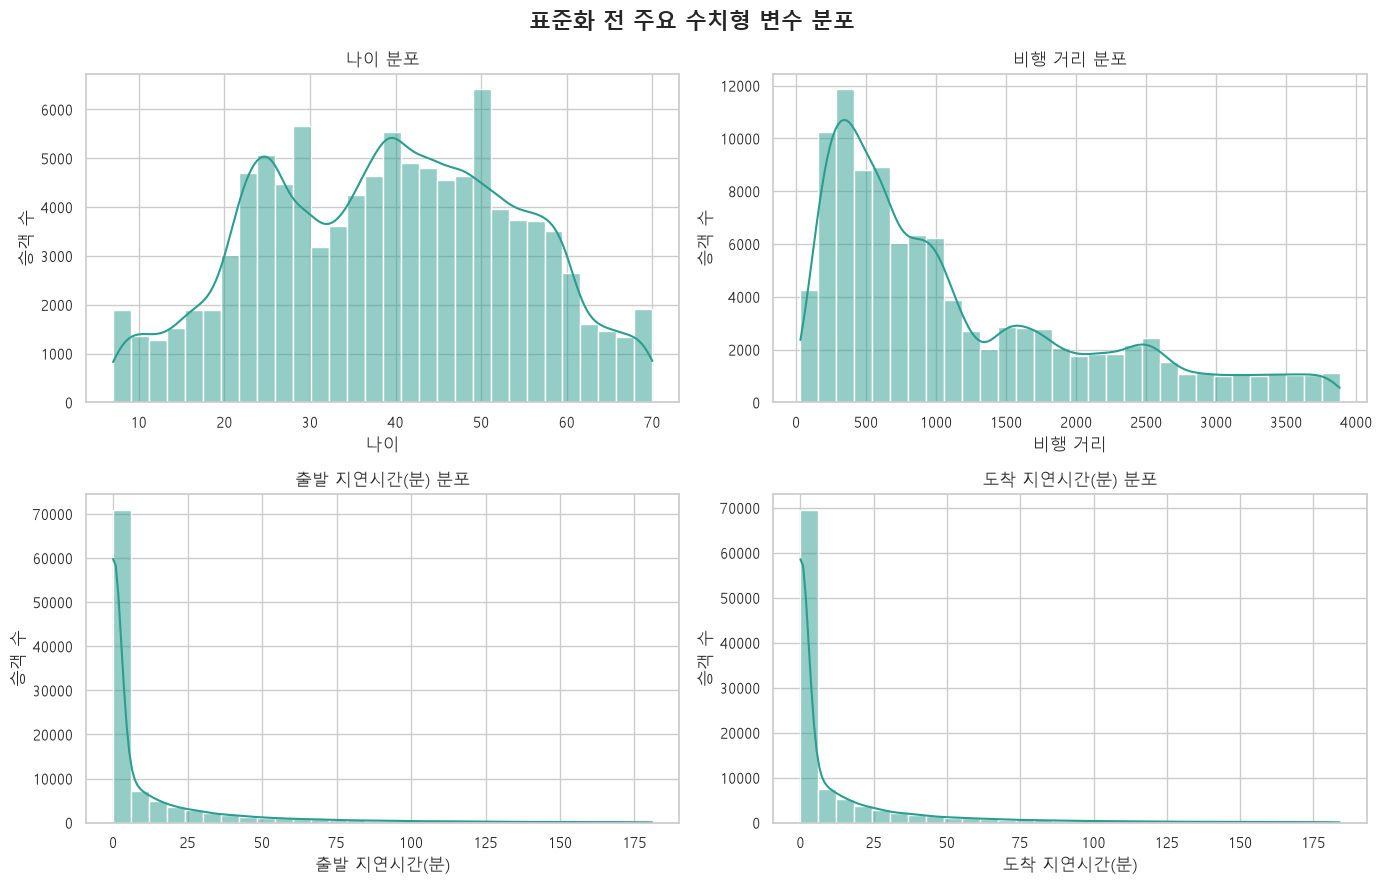

In [12]:
# 표준화 전 주요 수치형 변수 분포
continuous_features = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

continuous_korean = {
    "Age": "나이",
    "Flight Distance": "비행 거리",
    "Departure Delay in Minutes": "출발 지연시간(분)",
    "Arrival Delay in Minutes": "도착 지연시간(분)"
}

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9)
)

for ax, feature in zip(axes.flat, continuous_features):
    # 그래프를 보기 쉽게 상위 1%만 화면에서 제외
    # 원본 train 데이터는 변경되지 않음
    upper = train[feature].quantile(0.99)

    plot_values = train.loc[
        train[feature].notna()
        & (train[feature] <= upper),
        feature
    ]

    sns.histplot(
        plot_values,
        bins=30,
        kde=True,
        color="#2A9D8F",
        ax=ax
    )

    ax.set(
        title=f"{continuous_korean[feature]} 분포",
        xlabel=continuous_korean[feature],
        ylabel="승객 수"
    )

plt.suptitle(
    "표준화 전 주요 수치형 변수 분포",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

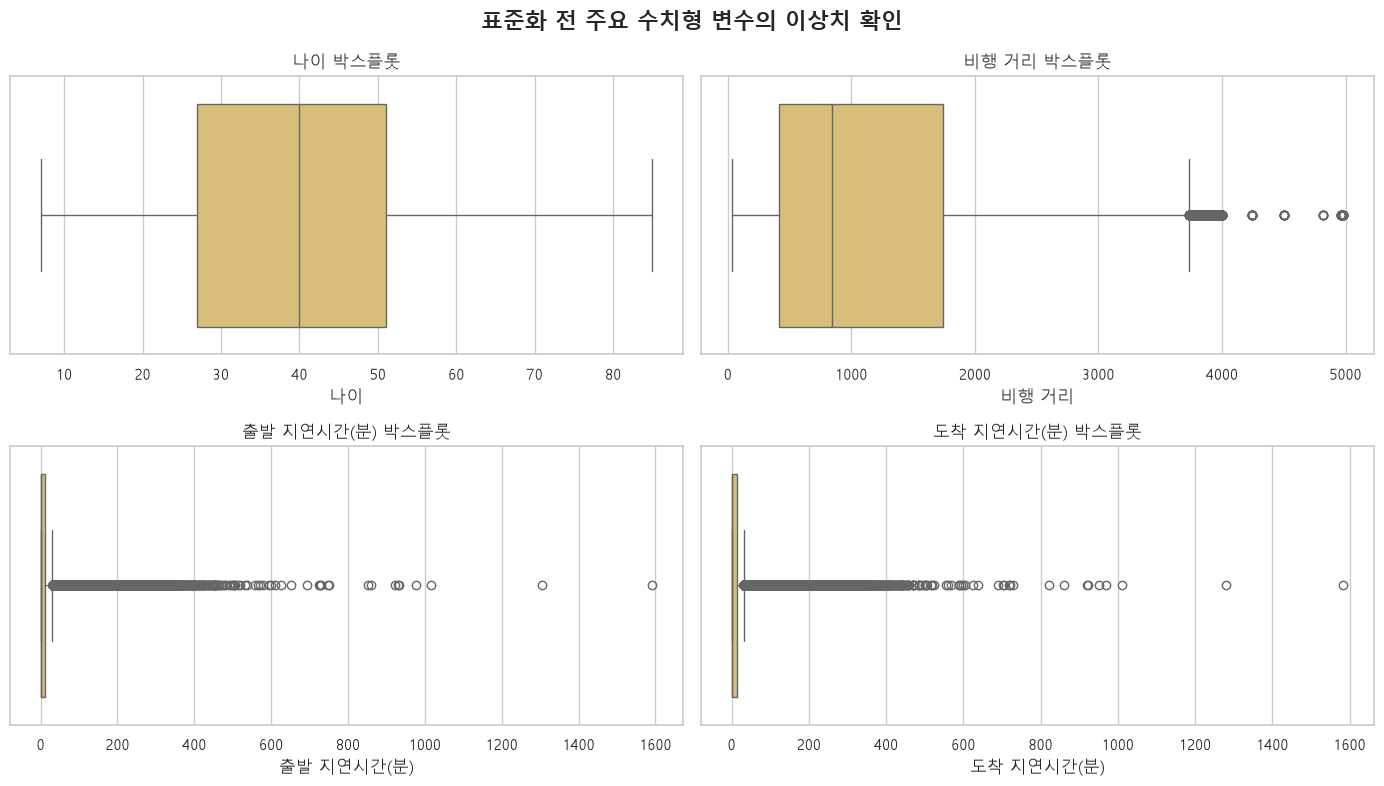

In [13]:
# 표준화 전 수치형 변수의 이상치 확인
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 8)
)

for ax, feature in zip(axes.flat, continuous_features):
    sns.boxplot(
        x=train[feature],
        color="#E9C46A",
        ax=ax
    )

    ax.set(
        title=f"{continuous_korean[feature]} 박스플롯",
        xlabel=continuous_korean[feature]
    )

plt.suptitle(
    "표준화 전 주요 수치형 변수의 이상치 확인",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### EDA 해석 기준

- 온라인 탑승, 기내 엔터테인먼트, 좌석 편안함 등에서 만족·불만족 집단 차이를 확인한다.
- 여행 목적, 좌석 등급, 고객 유형별 만족률 차이를 비교한다.
- 출발·도착 지연은 서로 매우 강하게 연관되므로 선형 모델에서는 다중공선성을 점검한다.
- 시각화 결과는 관련성을 보여줄 뿐 인과관계를 증명하지 않는다.

## 데이터 전처리

도착 지연시간은 오른쪽으로 치우치고 극단값의 영향을 크게 받으므로 평균보다 중앙값으로 결측치를 대체하였다. 중앙값은 학습 데이터에서만 계산해 validation과 test에 적용하였다. 장시간 지연은 오류라고 단정할 수 없는 실제 운항 정보이며 만족도에 영향을 줄 수 있으므로 이상치를 삭제하지 않았다.

In [14]:
train.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [15]:
# 모델에서 제외할 변수
drop_cols = ["Unnamed: 0", "id"]

# 입력 변수와 타깃 분리
X = train.drop(
    ["satisfaction", *drop_cols],
    axis=1
).copy()

y = train["satisfaction"].map({
    "neutral or dissatisfied": 0,
    "satisfied": 1
})

# 최종 평가용 test 데이터
X_test = test.drop(
    ["satisfaction", *drop_cols],
    axis=1
).copy()

y_test = test["satisfaction"].map({
    "neutral or dissatisfied": 0,
    "satisfied": 1
})

print("X 크기:", X.shape)
print("y 크기:", y.shape)
print("X_test 크기:", X_test.shape)

print("\n타깃 분포")
print(y.value_counts())

X 크기: (103904, 22)
y 크기: (103904,)
X_test 크기: (25976, 22)

타깃 분포
satisfaction
0    58879
1    45025
Name: count, dtype: int64


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=10,
    stratify=y
)

# Pipeline 교차검증용 원본 데이터 보존
X_train_raw = X_train.copy()
X_valid_raw = X_valid.copy()
X_test_raw = X_test.copy()

print("학습 데이터:", X_train.shape)
print("검증 데이터:", X_valid.shape)

print("\n학습 클래스 비율")
print(y_train.value_counts(normalize=True))

print("\n검증 클래스 비율")
print(y_valid.value_counts(normalize=True))

학습 데이터: (83123, 22)
검증 데이터: (20781, 22)

학습 클래스 비율
satisfaction
0    0.566666
1    0.433334
Name: proportion, dtype: float64

검증 클래스 비율
satisfaction
0    0.566671
1    0.433329
Name: proportion, dtype: float64


In [17]:
# 학습 데이터에서만 중앙값 계산
arrival_median = X_train[
    "Arrival Delay in Minutes"
].median()

print("도착 지연시간 중앙값:", arrival_median)

도착 지연시간 중앙값: 0.0


In [18]:
X_train["Arrival Delay in Minutes"] = (
    X_train["Arrival Delay in Minutes"]
    .fillna(arrival_median)
)

X_valid["Arrival Delay in Minutes"] = (
    X_valid["Arrival Delay in Minutes"]
    .fillna(arrival_median)
)

X_test["Arrival Delay in Minutes"] = (
    X_test["Arrival Delay in Minutes"]
    .fillna(arrival_median)
)

In [19]:
print(
    "학습 결측치:",
    X_train.isna().sum().sum()
)

print(
    "검증 결측치:",
    X_valid.isna().sum().sum()
)

print(
    "테스트 결측치:",
    X_test.isna().sum().sum()
)

학습 결측치: 0
검증 결측치: 0
테스트 결측치: 0


In [20]:
categorical_cols = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class"
]

print(
    X_train[categorical_cols]
    .nunique()
)

Gender            2
Customer Type     2
Type of Travel    2
Class             3
dtype: int64


In [21]:
# 원핫인코딩
X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=False,
    dtype=int
)

X_valid_encoded = pd.get_dummies(
    X_valid,
    columns=categorical_cols,
    drop_first=False,
    dtype=int
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=False,
    dtype=int
)

In [22]:
X_valid_encoded = X_valid_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

print("인코딩 후 학습:", X_train_encoded.shape)
print("인코딩 후 검증:", X_valid_encoded.shape)
print("인코딩 후 테스트:", X_test_encoded.shape)

print(
    "학습·검증 컬럼 일치:",
    X_train_encoded.columns.equals(
        X_valid_encoded.columns
    )
)

print(
    "학습·테스트 컬럼 일치:",
    X_train_encoded.columns.equals(
        X_test_encoded.columns
    )
)

인코딩 후 학습: (83123, 27)
인코딩 후 검증: (20781, 27)
인코딩 후 테스트: (25976, 27)
학습·검증 컬럼 일치: True
학습·테스트 컬럼 일치: True


In [23]:
# 결정트리와 랜덤 포레스트용
X_train_tree = X_train_encoded.copy()
X_valid_tree = X_valid_encoded.copy()
X_test_tree = X_test_encoded.copy()

In [24]:
from sklearn.preprocessing import StandardScaler

numeric_cols = X_train.select_dtypes(
    include="number"
).columns.tolist()

scaler = StandardScaler()

X_train_scaled = X_train_encoded.copy()
X_valid_scaled = X_valid_encoded.copy()
X_test_scaled = X_test_encoded.copy()

In [25]:
X_train_scaled[numeric_cols] = scaler.fit_transform(
    X_train_encoded[numeric_cols]
)

X_valid_scaled[numeric_cols] = scaler.transform(
    X_valid_encoded[numeric_cols]
)

X_test_scaled[numeric_cols] = scaler.transform(
    X_test_encoded[numeric_cols]
)

In [26]:
print("로지스틱 회귀용 학습 데이터:")
print(X_train_scaled.shape)

print("\n트리 모델용 학습 데이터:")
print(X_train_tree.shape)

print("\n남은 결측치:")
print("로지스틱:", X_train_scaled.isna().sum().sum())
print("트리:", X_train_tree.isna().sum().sum())

display(
    X_train_scaled.head()
)

로지스틱 회귀용 학습 데이터:
(83123, 27)

트리 모델용 학습 데이터:
(83123, 27)

남은 결측치:
로지스틱: 0
트리: 0


,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Arrival Delay in Minutes,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
64704,-0.685703,-0.822986,1.712771,-1.351698,1.604449,0.803656,1.350897,1.297397,1.183950,1.231709,...,-0.394067,0,1,1,0,0,1,0,1,0
69973,0.636889,-0.707799,0.958129,1.275572,0.888444,1.587785,-0.152998,0.556021,-0.334788,0.481686,...,-0.394067,1,0,1,0,1,0,0,1,0
2316,-1.413128,-0.545536,1.712771,-0.038063,0.172440,0.019527,1.350897,1.297397,1.183950,1.231709,...,-0.394067,1,0,1,0,1,0,0,1,0
94551,1.099796,-0.522499,-0.551153,0.618755,0.172440,0.803656,-0.904946,-0.926731,-1.094157,-1.018359,...,-0.212712,0,1,1,0,1,0,0,1,0
97730,-0.553444,0.554246,0.958129,0.618755,0.888444,0.019527,-0.152998,0.556021,1.183950,-0.268336,...,-0.394067,0,1,1,0,0,1,0,1,0


In [27]:
print("결측치")
print("학습:", X_train_scaled.isna().sum().sum())
print("검증:", X_valid_scaled.isna().sum().sum())
print("테스트:", X_test_scaled.isna().sum().sum())

print("\n데이터 크기")
print("학습:", X_train_scaled.shape)
print("검증:", X_valid_scaled.shape)
print("테스트:", X_test_scaled.shape)

print("\n컬럼 일치")
print(
    X_train_scaled.columns.equals(X_valid_scaled.columns),
    X_train_scaled.columns.equals(X_test_scaled.columns)
)

결측치
학습: 0
검증: 0
테스트: 0

데이터 크기
학습: (83123, 27)
검증: (20781, 27)
테스트: (25976, 27)

컬럼 일치
True True


In [28]:
scaling_comparison = pd.DataFrame({
    "표준화 전 평균": X_train[numeric_cols].mean(),
    "표준화 후 평균": X_train_scaled[numeric_cols].mean(),
    "표준화 전 표준편차": X_train[numeric_cols].std(ddof=0),
    "표준화 후 표준편차": X_train_scaled[numeric_cols].std(ddof=0)
})

display(
    scaling_comparison.loc[
        [
            "Age",
            "Flight Distance",
            "Departure Delay in Minutes",
            "Arrival Delay in Minutes"
        ]
    ].round(3)
)

,표준화 전 평균,표준화 후 평균,표준화 전 표준편차,표준화 후 표준편차
Age,39.369,-0.0,15.122,1.0
Flight Distance,1190.652,0.0,998.380,1.0
Departure Delay in Minutes,14.868,-0.0,38.070,1.0
Arrival Delay in Minutes,15.210,-0.0,38.598,1.0


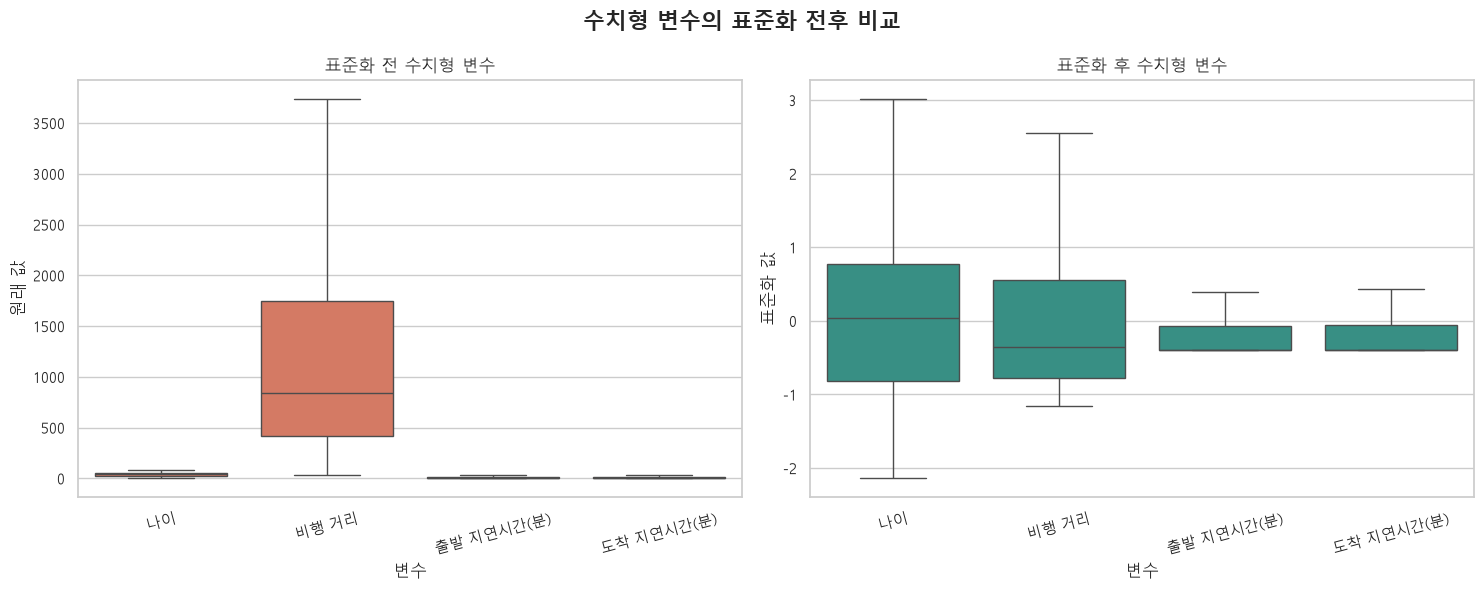

In [29]:
check_cols = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

# 그래프 표시용 변수명 변경
before_plot = (
    X_train[check_cols]
    .rename(columns=continuous_korean)
)

after_plot = (
    X_train_scaled[check_cols]
    .rename(columns=continuous_korean)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

# 표준화 전
sns.boxplot(
    data=before_plot,
    showfliers=False,
    color="#E76F51",
    ax=axes[0]
)

axes[0].set(
    title="표준화 전 수치형 변수",
    xlabel="변수",
    ylabel="원래 값"
)

axes[0].tick_params(
    axis="x",
    rotation=15
)

# 표준화 후
sns.boxplot(
    data=after_plot,
    showfliers=False,
    color="#2A9D8F",
    ax=axes[1]
)

axes[1].set(
    title="표준화 후 수치형 변수",
    xlabel="변수",
    ylabel="표준화 값"
)

axes[1].tick_params(
    axis="x",
    rotation=15
)

plt.suptitle(
    "수치형 변수의 표준화 전후 비교",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [30]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def get_clf_eval(model_name, y_true, pred, pred_proba):
    result = {
        "모델": model_name,
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred),
        "F1-score": f1_score(y_true, pred),
        "ROC-AUC": roc_auc_score(y_true, pred_proba)
    }

    print(f"[{model_name}]")
    print("혼동행렬")
    print(confusion_matrix(y_true, pred))

    return result

## 이진 분류 모델링

### 수업 내용의 확장 적용 근거

본 프로젝트의 결측치 대체, 원-핫 인코딩, 표준화, 교차검증 및 Dummy baseline의 원리는 모두 수업에서 학습한 내용이다. 다만 다음과 같은 이유로 일부 sklearn 도구를 확장 적용하였다.

- SimpleImputer: 수업의 fillna와 같은 중앙값 대체를 각 교차검증 fold의 학습 데이터 내부에서만 수행하여 데이터 누수를 방지하기 위해 사용하였다.
- ColumnTransformer: 수치형과 범주형 변수에 서로 다른 전처리를 적용하기 위해 사용하였다. 수치형 변수에는 중앙값 대체를 적용하고 로지스틱 회귀에서만 추가로 표준화했으며, 범주형 변수에는 One-Hot Encoding을 적용하였다. 이를 통해 교차검증, validation, test에 모델별로 동일한 변환을 재현하였다.
- StratifiedKFold: 일반 KFold를 분류 문제에 맞게 확장하여 각 fold의 만족·불만족 클래스 비율을 유지하기 위해 사용하였다.
- DummyClassifier: 수업에서 직접 구현한 Dummy baseline과 동일한 원리를 sklearn의 공식 구현체로 재현하였다.

이 도구들은 새로운 모델링 원리를 추가하기 위한 것이 아니라, 수업에서 배운 전처리와 평가 방법을 데이터 누수 없이 재현 가능하게 구현하기 위해 사용하였다.

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

categorical_cols = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class"
]

numeric_cols = (
    X_train_raw
    .select_dtypes(include="number")
    .columns
    .tolist()
)

# 로지스틱 회귀용 전처리
logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="median")
                ),
                (
                    "scaler",
                    StandardScaler()
                )
            ]),
            numeric_cols
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ]
)

# 트리 계열 모델용 전처리
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_cols
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ]
)

In [32]:
# Dummy Classifier
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(
    strategy="most_frequent"
)

dummy_clf.fit(
    X_train_scaled,
    y_train
)

dummy_pred = dummy_clf.predict(
    X_valid_scaled
)

dummy_pred_proba = dummy_clf.predict_proba(
    X_valid_scaled
)[:, 1]

dummy_result = get_clf_eval(
    "Dummy Classifier",
    y_valid,
    dummy_pred,
    dummy_pred_proba
)

dummy_result

[Dummy Classifier]
혼동행렬
[[11776     0]
 [ 9005     0]]


{'모델': 'Dummy Classifier',
 'Accuracy': 0.5666714787546316,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1-score': 0.0,
 'ROC-AUC': 0.5}

In [33]:
# 로지스틱 회귀
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(
    solver="liblinear",
    max_iter=1000,
    random_state=10
)

lr_clf.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr_clf.predict(
    X_valid_scaled
)

lr_pred_proba = lr_clf.predict_proba(
    X_valid_scaled
)[:, 1]

lr_result = get_clf_eval(
    "Logistic Regression",
    y_valid,
    lr_pred,
    lr_pred_proba
)

lr_result

[Logistic Regression]
혼동행렬
[[10669  1107]
 [ 1473  7532]]


{'모델': 'Logistic Regression',
 'Accuracy': 0.8758481305038256,
 'Precision': 0.8718601690010418,
 'Recall': 0.8364242087729039,
 'F1-score': 0.8537746542734074,
 'ROC-AUC': 0.9263054153187844}

In [34]:
# 결정트리
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(
    random_state=10
)

dt_clf.fit(
    X_train_tree,
    y_train
)

dt_pred = dt_clf.predict(
    X_valid_tree
)

dt_pred_proba = dt_clf.predict_proba(
    X_valid_tree
)[:, 1]

dt_result = get_clf_eval(
    "Decision Tree",
    y_valid,
    dt_pred,
    dt_pred_proba
)

dt_result

[Decision Tree]
혼동행렬
[[11191   585]
 [  549  8456]]


{'모델': 'Decision Tree',
 'Accuracy': 0.9454309224772629,
 'Precision': 0.9352947682778454,
 'Recall': 0.9390338700721821,
 'F1-score': 0.9371605896043445,
 'ROC-AUC': 0.9446782801447867}

In [35]:
# 랜덤 포레스트
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=10,
    n_jobs=-1
)

rf_clf.fit(
    X_train_tree,
    y_train
)

rf_pred = rf_clf.predict(
    X_valid_tree
)

rf_pred_proba = rf_clf.predict_proba(
    X_valid_tree
)[:, 1]

rf_result = get_clf_eval(
    "Random Forest",
    y_valid,
    rf_pred,
    rf_pred_proba
)

rf_result

[Random Forest]
혼동행렬
[[11542   234]
 [  552  8453]]


{'모델': 'Random Forest',
 'Accuracy': 0.9621769885953515,
 'Precision': 0.9730631978818924,
 'Recall': 0.9387007218212104,
 'F1-score': 0.9555731404024418,
 'ROC-AUC': 0.9942421641132341}

In [36]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    eval_metric="logloss",
    random_state=10,
    n_jobs=-1
)

xgb_clf.fit(
    X_train_tree,
    y_train
)

xgb_pred = xgb_clf.predict(
    X_valid_tree
)

xgb_pred_proba = xgb_clf.predict_proba(
    X_valid_tree
)[:, 1]

xgb_result = get_clf_eval(
    "XGBoost",
    y_valid,
    xgb_pred,
    xgb_pred_proba
)

xgb_result

[XGBoost]
혼동행렬
[[11549   227]
 [  585  8420]]


{'모델': 'XGBoost',
 'Accuracy': 0.9609258457244598,
 'Precision': 0.9737481207355152,
 'Recall': 0.9350360910605219,
 'F1-score': 0.9539995467935645,
 'ROC-AUC': 0.9940383786257031}

In [37]:
from lightgbm import LGBMClassifier

lgbm_clf = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=10,
    n_jobs=-1,
    verbosity=-1
)

lgbm_clf.fit(
    X_train_tree,
    y_train
)

lgbm_pred = lgbm_clf.predict(
    X_valid_tree
)

lgbm_pred_proba = lgbm_clf.predict_proba(
    X_valid_tree
)[:, 1]

lgbm_result = get_clf_eval(
    "LightGBM",
    y_valid,
    lgbm_pred,
    lgbm_pred_proba
)

lgbm_result

[LightGBM]
혼동행렬
[[11576   200]
 [  567  8438]]


{'모델': 'LightGBM',
 'Accuracy': 0.9630912853086955,
 'Precision': 0.9768464922435749,
 'Recall': 0.937034980566352,
 'F1-score': 0.9565266678002607,
 'ROC-AUC': 0.9950617240874635}

In [38]:
# 모델 비교표
all_model_results = pd.DataFrame([
    dummy_result,
    lr_result,
    dt_result,
    rf_result,
    xgb_result,
    lgbm_result
])

all_model_results = (
    all_model_results
    .set_index("모델")
    .sort_values("F1-score", ascending=False)
)

display(all_model_results.round(4))

,Accuracy,Precision,Recall,F1-score,ROC-AUC
모델,,,,,
LightGBM,0.9631,0.9768,0.9370,0.9565,0.9951
Random Forest,0.9622,0.9731,0.9387,0.9556,0.9942
XGBoost,0.9609,0.9737,0.9350,0.9540,0.9940
Decision Tree,0.9454,0.9353,0.9390,0.9372,0.9447
Logistic Regression,0.8758,0.8719,0.8364,0.8538,0.9263
Dummy Classifier,0.5667,0.0000,0.0000,0.0000,0.5000


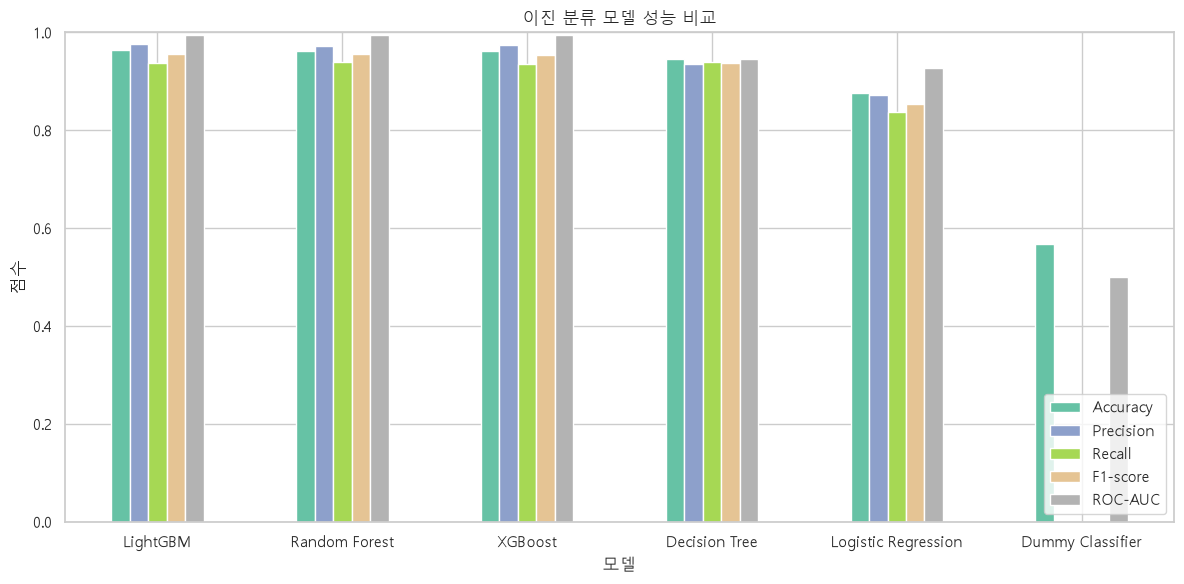

In [39]:
# 비교 그래프
all_model_results.plot(
    kind="bar",
    figsize=(12, 6),
    ylim=(0, 1),
    colormap="Set2"
)

plt.title("이진 분류 모델 성능 비교")
plt.xlabel("모델")
plt.ylabel("점수")
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

### 교차검증

타깃 비율은 중립·불만족 약 56.7%, 만족 약 43.3%로 심각한
불균형은 아니다.

그러나 본 프로젝트에서는 실제 불만족 고객을 만족으로 잘못 분류하는
FP가 고객 관리 대상을 놓치게 만들 수 있으므로 FP를 중요한 오류로
정의하였다. 이에 따라 만족 예측의 Precision과 불만족 고객에 대한
FPR을 우선적으로 확인한다.

다만 Precision만 높이기 위해 만족 예측을 지나치게 줄이면 FN이
증가할 수 있으므로 Recall과 F1-score도 함께 평가한다.

Stratified 5-Fold를 사용하여 각 fold의 클래스 비율을 유지하고,
전처리와 모델을 Pipeline으로 구성하여 각 fold의 학습 데이터에서만
결측치 대체와 인코딩이 학습되도록 하였다.

모델 종류와 하이퍼파라미터는 Precision과 Recall의 전반적인 균형을
평가하기 위해 교차검증 F1-score를 기준으로 선택하였다.

이후 최종 모델의 분류 임계값은 비즈니스상 중요한 FP를 줄이기 위해
validation 데이터에서 Precision, FPR, Recall 및 F1-score를 함께
고려하여 별도로 결정하였다.

In [40]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=10
)

cv_models = [
    (
        "Logistic Regression",
        Pipeline([
            (
                "preprocessor",
                logistic_preprocessor
            ),
            (
                "model",
                LogisticRegression(
                    solver="liblinear",
                    max_iter=1000,
                    random_state=10
                )
            )
        ])
    ),
    (
        "Decision Tree",
        Pipeline([
            (
                "preprocessor",
                tree_preprocessor
            ),
            (
                "model",
                DecisionTreeClassifier(
                    random_state=10
                )
            )
        ])
    ),
    (
        "Random Forest",
        Pipeline([
            (
                "preprocessor",
                tree_preprocessor
            ),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=100,
                    random_state=10,
                    n_jobs=1
                )
            )
        ])
    ),
    (
        "XGBoost",
        Pipeline([
            (
                "preprocessor",
                tree_preprocessor
            ),
            (
                "model",
                XGBClassifier(
                    n_estimators=200,
                    learning_rate=0.05,
                    max_depth=6,
                    eval_metric="logloss",
                    random_state=10,
                    n_jobs=1
                )
            )
        ])
    ),
    (
        "LightGBM",
        Pipeline([
            (
                "preprocessor",
                tree_preprocessor
            ),
            (
                "model",
                LGBMClassifier(
                    n_estimators=200,
                    learning_rate=0.05,
                    random_state=10,
                    n_jobs=1,
                    verbosity=-1
                )
            )
        ])
    )
]

cv_results = []

for name, pipeline_model in cv_models:
    scores = cross_val_score(
        pipeline_model,
        X_train_raw,
        y_train,
        scoring="f1",
        cv=cv,
        n_jobs=-1
    )

    cv_results.append({
        "모델": name,
        "평균 F1": scores.mean(),
        "표준편차": scores.std()
    })

cv_result_df = (
    pd.DataFrame(cv_results)
    .sort_values(
        "평균 F1",
        ascending=False
    )
)

display(
    cv_result_df
    .round(4)
    .style
    .hide(axis="index")
)

모델,평균 F1,표준편차
LightGBM,0.957700,0.001700
Random Forest,0.955900,0.001100
XGBoost,0.954000,0.002000
Decision Tree,0.936000,0.001400
Logistic Regression,0.852900,0.001600


### LightGBM 하이퍼파라미터 튜닝

교차검증에서 LightGBM의 평균 F1-score가 0.9577로 가장 높았지만 Random Forest의 0.9562와 차이는 작았다. 따라서 LightGBM의 압도적인 우위를 주장하지 않고, 평균 성능과 튜닝 결과를 종합하여 최종 모델로 선택하였다.

GridSearchCV에서는 계산량을 통제하면서 대표적인 복잡도를 비교하기 위해 트리 수 100·200, 학습률 0.05·0.1, 리프 수 15·31·63, 최대 깊이 제한 없음·10을 탐색하였다. 총 24개 조합을 Stratified 5-Fold로 평가하여 120회 학습하였다.

In [41]:
# RandomizedSearchCV - 무작위 탐색, 빠름 / 최적 조합을 건너뛸 수 있음
# GridSearchCV - 모든 조합 탐색, 꼼꼼함 / 시간이 더 걸림

In [42]:
from sklearn.model_selection import GridSearchCV

lgbm_pipeline = Pipeline([
    (
        "preprocessor",
        tree_preprocessor
    ),
    (
        "model",
        LGBMClassifier(
            random_state=10,
            n_jobs=1,
            verbosity=-1
        )
    )
])

lgbm_params = {
    "model__n_estimators": [
        100,
        200
    ],
    "model__learning_rate": [
        0.05,
        0.1
    ],
    "model__num_leaves": [
        15,
        31,
        63
    ],
    "model__max_depth": [
        -1,
        10
    ]
}

lgbm_grid = GridSearchCV(
    estimator=lgbm_pipeline,
    param_grid=lgbm_params,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

lgbm_grid.fit(
    X_train_raw,
    y_train
);

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [43]:
print("최적 파라미터:")
print(lgbm_grid.best_params_)

print(
    "최고 교차검증 F1:",
    round(lgbm_grid.best_score_, 4)
)

최적 파라미터:
{'model__learning_rate': 0.05, 'model__max_depth': -1, 'model__n_estimators': 200, 'model__num_leaves': 63}
최고 교차검증 F1: 0.9591


In [44]:
best_lgbm = lgbm_grid.best_estimator_

best_lgbm_pred = best_lgbm.predict(
    X_valid_raw
)

best_lgbm_proba = best_lgbm.predict_proba(
    X_valid_raw
)[:, 1]

best_lgbm_result = get_clf_eval(
    "Tuned LightGBM",
    y_valid,
    best_lgbm_pred,
    best_lgbm_proba
)

display(
    pd.DataFrame([
        best_lgbm_result,
        rf_result
    ])
    .round(4)
    .style
    .hide(axis="index")
)

[Tuned LightGBM]
혼동행렬
[[11589   187]
 [  556  8449]]


모델,Accuracy,Precision,Recall,F1-score,ROC-AUC
Tuned LightGBM,0.964200,0.978300,0.938300,0.957900,0.995400
Random Forest,0.962200,0.973100,0.938700,0.955600,0.994200


In [45]:
train_f1 = f1_score(
    y_train,
    best_lgbm.predict(X_train_raw)
)

valid_f1 = f1_score(
    y_valid,
    best_lgbm_pred
)

print("학습 F1:",round(train_f1, 4))

print("검증 F1:",round(valid_f1, 4))

print("성능 차이:",round(train_f1 - valid_f1, 4))

학습 F1: 0.9672
검증 F1: 0.9579
성능 차이: 0.0094


In [46]:
# FP 감소를 위한 validation 임계값 분석
valid_proba = best_lgbm.predict_proba(
    X_valid_raw
)[:, 1]

threshold_results = []

for threshold in np.arange(
    0.50,
    0.91,
    0.01
):
    threshold_pred = (
        valid_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_valid,
        threshold_pred
    ).ravel()

    threshold_results.append({
        "임계값": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "FPR": fp / (tn + fp),
        "Precision": precision_score(
            y_valid,
            threshold_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_valid,
            threshold_pred,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_valid,
            threshold_pred,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(
    threshold_df
    .round(4)
    .style
    .hide(axis="index")
)

임계값,TN,FP,FN,TP,FPR,Precision,Recall,F1-score
0.500000,11589,187,556,8449,0.015900,0.978300,0.938300,0.957900
0.510000,11598,178,559,8446,0.015100,0.979400,0.937900,0.958200
0.520000,11602,174,570,8435,0.014800,0.979800,0.936700,0.957800
0.530000,11607,169,577,8428,0.014400,0.980300,0.935900,0.957600
0.540000,11610,166,587,8418,0.014100,0.980700,0.934800,0.957200
0.550000,11619,157,597,8408,0.013300,0.981700,0.933700,0.957100
0.560000,11624,152,614,8391,0.012900,0.982200,0.931800,0.956300
0.570000,11628,148,619,8386,0.012600,0.982700,0.931300,0.956300
0.580000,11630,146,626,8379,0.012400,0.982900,0.930500,0.956000
0.590000,11635,141,632,8373,0.012000,0.983400,0.929800,0.955900


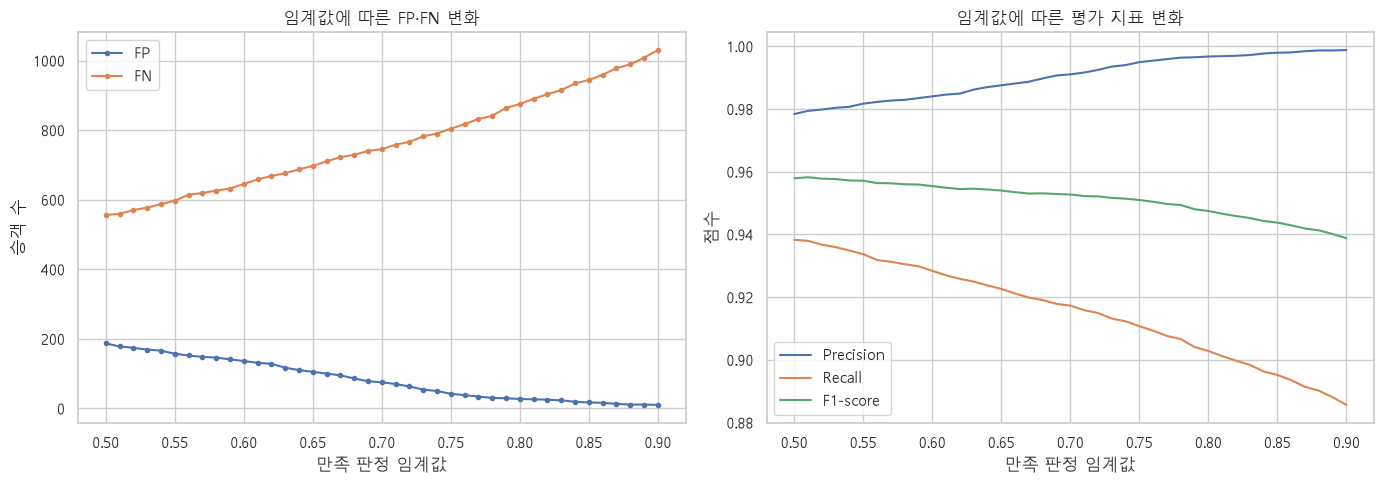

In [47]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].plot(
    threshold_df["임계값"],
    threshold_df["FP"],
    marker="o",
    markersize=3,
    label="FP"
)
axes[0].plot(
    threshold_df["임계값"],
    threshold_df["FN"],
    marker="o",
    markersize=3,
    label="FN"
)
axes[0].set(
    title="임계값에 따른 FP·FN 변화",
    xlabel="만족 판정 임계값",
    ylabel="승객 수"
)
axes[0].legend()

axes[1].plot(
    threshold_df["임계값"],
    threshold_df["Precision"],
    label="Precision"
)
axes[1].plot(
    threshold_df["임계값"],
    threshold_df["Recall"],
    label="Recall"
)
axes[1].plot(
    threshold_df["임계값"],
    threshold_df["F1-score"],
    label="F1-score"
)
axes[1].set(
    title="임계값에 따른 평가 지표 변화",
    xlabel="만족 판정 임계값",
    ylabel="점수"
)
axes[1].legend()

plt.tight_layout()
plt.show()

In [48]:
# 대표 임계값 3개 비교
comparison_thresholds = [
    0.50,
    0.75,
    0.81
]

threshold_comparison = threshold_df[
    threshold_df["임계값"].apply(
        lambda x: any(
            np.isclose(
                x,
                target
            )
            for target in comparison_thresholds
        )
    )
][[
    "임계값",
    "FP",
    "FN",
    "FPR",
    "Precision",
    "Recall",
    "F1-score"
]].copy()

display(
    threshold_comparison
    .round({
        "임계값": 2,
        "FPR": 4,
        "Precision": 4,
        "Recall": 4,
        "F1-score": 4
    })
    .style
    .hide(axis="index")
    .highlight_max(
        subset=[
            "Precision",
            "Recall",
            "F1-score"
        ],
        color="#A83030"
    )
    .highlight_min(
        subset=[
            "FP",
            "FN",
            "FPR"
        ],
        color="#A83030"
    )
)

임계값,FP,FN,FPR,Precision,Recall,F1-score
0.500000,187,556,0.015900,0.978300,0.938300,0.957900
0.750000,42,804,0.003600,0.994900,0.910700,0.951000
0.810000,26,890,0.002200,0.996800,0.901200,0.946600


In [49]:
# 임계값 0.75와 0.81의 비용 손익분기 분석

threshold_075 = (
    threshold_df[
        np.isclose(
            threshold_df["임계값"],
            0.75
        )
    ]
    .iloc[0]
)

threshold_081 = (
    threshold_df[
        np.isclose(
            threshold_df["임계값"],
            0.81
        )
    ]
    .iloc[0]
)

fp_075 = int(
    threshold_075["FP"]
)
fn_075 = int(
    threshold_075["FN"]
)

fp_081 = int(
    threshold_081["FP"]
)
fn_081 = int(
    threshold_081["FN"]
)

# 두 임계값의 비용이 같아지는 FP/FN 비용 비율
break_even_ratio = (
    (fn_081 - fn_075)
    / (fp_075 - fp_081)
)

cost_break_even_df = pd.DataFrame({
    "임계값": [
        0.75,
        0.81
    ],
    "FP": [
        fp_075,
        fp_081
    ],
    "FN": [
        fn_075,
        fn_081
    ]
})

display(
    cost_break_even_df
    .style
    .hide(axis="index")
)

print(
    "FP와 FN의 손익분기 비용비율:",
    f"{break_even_ratio:.3f}"
)

print(
    f"FP 비용이 FN의 {break_even_ratio:.3f}배보다 크면 "
    "임계값 0.81이 비용 측면에서 유리합니다."
)

print(
    f"FP 비용이 FN의 {break_even_ratio:.3f}배보다 작으면 "
    "임계값 0.75가 비용 측면에서 유리합니다."
)

print(
    f"FP 비용이 FN의 {break_even_ratio:.3f}배와 같으면 "
    "두 임계값의 총비용은 동일합니다."
)

임계값,FP,FN
0.750000,42,804
0.810000,26,890


FP와 FN의 손익분기 비용비율: 5.375
FP 비용이 FN의 5.375배보다 크면 임계값 0.81이 비용 측면에서 유리합니다.
FP 비용이 FN의 5.375배보다 작으면 임계값 0.75가 비용 측면에서 유리합니다.
FP 비용이 FN의 5.375배와 같으면 두 임계값의 총비용은 동일합니다.


In [50]:
# FP 상대비용에 따른 두 임계값의 총비용 비교
cost_ratios = [
    1,
    2,
    5,
    break_even_ratio,
    6,
    10
]

cost_scenario_results = []

for fp_cost_ratio in cost_ratios:
    cost_075 = (
        fp_075 * fp_cost_ratio
        + fn_075
    )

    cost_081 = (
        fp_081 * fp_cost_ratio
        + fn_081
    )

    if np.isclose(
        cost_075,
        cost_081
    ):
        better_threshold = "동일"
    elif cost_075 < cost_081:
        better_threshold = "0.75"
    else:
        better_threshold = "0.81"

    cost_scenario_results.append({
        "FP 상대비용": fp_cost_ratio,
        "임계값 0.75 총비용": cost_075,
        "임계값 0.81 총비용": cost_081,
        "비용상 유리한 임계값": better_threshold
    })

cost_scenario_df = pd.DataFrame(
    cost_scenario_results
)

display(
    cost_scenario_df
    .round(3)
    .style
    .hide(axis="index")
)

FP 상대비용,임계값 0.75 총비용,임계값 0.81 총비용,비용상 유리한 임계값
1.000000,846.000000,916.000000,0.75
2.000000,888.000000,942.000000,0.75
5.000000,1014.000000,1020.000000,0.75
5.375000,1029.750000,1029.750000,동일
6.000000,1056.000000,1046.000000,0.81
10.000000,1224.000000,1150.000000,0.81


### 임계값별 비용 손익분기 분석

개념적으로 FP 비용에는 실제 불만족 고객을 만족 고객으로 잘못
분류함으로써 발생할 수 있는 고객 이탈 손실과 서비스 회복 기회 상실이
포함될 수 있다. 반면 FN 비용에는 실제 만족 고객을 불만족 고객으로
잘못 분류함으로써 발생하는 불필요한 상담과 마케팅 비용이 포함될 수
있다.

그러나 본 데이터에는 이러한 실제 비용 정보가 포함되어 있지 않아
금전적 비용을 직접 산정하지 않았다.

따라서 임계값 0.75와 0.81 중 어떤 기준이 비용 측면에서 유리한지
손익분기 비용비율을 계산하였다.

임계값 0.75에서는 FP 42건과 FN 804건, 임계값 0.81에서는
FP 26건과 FN 890건이 발생하였다. FP 한 건의 비용을
$C_{FP}$, FN 한 건의 비용을 $C_{FN}$이라고 하면 두 임계값의
총비용은 다음과 같다.

$$
Cost_{0.75}
=
42C_{FP}
+
804C_{FN}
$$

$$
Cost_{0.81}
=
26C_{FP}
+
890C_{FN}
$$

두 임계값의 총비용이 같아지는 조건은 다음과 같다.

$$
42C_{FP}+804C_{FN}
=
26C_{FP}+890C_{FN}
$$

이를 정리하면 다음과 같다.

$$
\frac{C_{FP}}{C_{FN}}
=
\frac{890-804}{42-26}
=
\frac{86}{16}
=
5.375
$$

따라서 FP의 단위 비용이 FN의 5.375배를 초과하면 임계값 0.81이
비용 측면에서 유리하고, 5.375배 미만이면 임계값 0.75가 유리하다.
정확히 5.375배인 경우 두 임계값의 총 오분류 비용은 동일하다.

본 데이터에는 실제 FP·FN 단위 비용이 포함되어 있지 않으므로
5.375배는 실제 항공사의 비용비율이 아니라, 두 임계값의 총비용이
같아지는 손익분기 비율이다.

실제 비용자료가 없는 상황에서 FP만 최소화하면 FN이 과도하게 증가할
수 있으므로, 본 프로젝트에서는 Precision 0.99 이상, Recall 0.91 이상,
F1-score 0.95 이상을 동시에 유지하는 범위에서 FP가 가장 적은
임계값을 선택하였다. 그 결과 임계값 0.75를 본 프로젝트의 최종 분류 임계값으로
선택하였다.

In [51]:
threshold_candidates = threshold_df[
    (threshold_df["Precision"] >= 0.99)
    & (threshold_df["Recall"] >= 0.91)
    & (threshold_df["F1-score"] >= 0.95)
]

best_threshold_row = (
    threshold_candidates
    .sort_values(
        [
            "FP",
            "F1-score"
        ],
        ascending=[
            True,
            False
        ]
    )
    .iloc[0]
)

best_threshold = (
    best_threshold_row["임계값"]
)

print(
    "선택한 임계값:",
    round(best_threshold, 2)
)

display(
    best_threshold_row
    .to_frame("선택 결과")
    .round(4)
)

선택한 임계값: 0.75


,선택 결과
임계값,0.7500
TN,11734.0000
FP,42.0000
FN,804.0000
TP,8201.0000
FPR,0.0036
Precision,0.9949
Recall,0.9107
F1-score,0.9510


### 최종 임계값 선택

기본 임계값 0.5는 validation F1-score가 가장 높았지만 FP가
187명 발생하였다. 반면 임계값 0.75에서는 FP가 42명으로 약
77.5% 감소했으며, Precision 0.9949, Recall 0.9107,
F1-score 0.9510을 유지하였다.

임계값 0.81은 FP가 26명으로 더 적었지만 FN이 890명까지 증가하고
F1-score가 0.9466으로 낮아졌다. 따라서 FP 감소와 전체 예측 성능의
균형을 고려하여 0.75를 최종 임계값으로 선택하였다.

임계값은 validation 데이터에서만 결정하였으며, test 데이터에는
선택된 0.75를 변경하지 않고 적용하였다.

In [52]:
# 독립 test에는 validation에서 선택한 임계값을 적용
final_proba = best_lgbm.predict_proba(
    X_test_raw
)[:, 1]

final_pred = (
    final_proba >= best_threshold
).astype(int)

final_result = get_clf_eval(
    f"Final LightGBM (threshold={best_threshold:.2f})",
    y_test,
    final_pred,
    final_proba
)

final_result_df = pd.DataFrame([
    final_result
]).round(4)

display(
    final_result_df
    .style
    .hide(axis="index")
)

[Final LightGBM (threshold=0.75)]
혼동행렬
[[14515    58]
 [ 1001 10402]]


모델,Accuracy,Precision,Recall,F1-score,ROC-AUC
Final LightGBM (threshold=0.75),0.959200,0.994500,0.912200,0.951600,0.995300


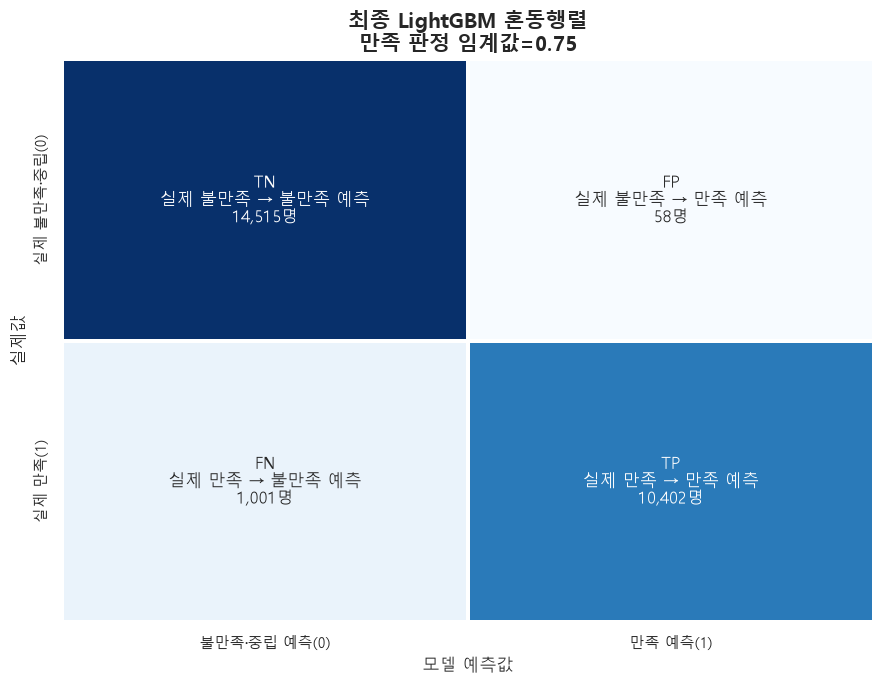

TN: 14,515명
FP: 58명
FN: 1,001명
TP: 10,402명
FPR: 0.0040


In [53]:
# 최종 test TN·FP·FN·TP 혼동행렬 시각화
final_cm = confusion_matrix(
    y_test,
    final_pred
)

tn, fp, fn, tp = final_cm.ravel()

confusion_text = np.array([
    [
        f"TN\n실제 불만족 → 불만족 예측\n{tn:,}명",
        f"FP\n실제 불만족 → 만족 예측\n{fp:,}명"
    ],
    [
        f"FN\n실제 만족 → 불만족 예측\n{fn:,}명",
        f"TP\n실제 만족 → 만족 예측\n{tp:,}명"
    ]
])

plt.figure(figsize=(9, 7))

sns.heatmap(
    final_cm,
    annot=confusion_text,
    fmt="",
    cmap="Blues",
    cbar=False,
    linewidths=1.5,
    linecolor="white",
    annot_kws={
        "fontsize": 12
    },
    xticklabels=[
        "불만족·중립 예측(0)",
        "만족 예측(1)"
    ],
    yticklabels=[
        "실제 불만족·중립(0)",
        "실제 만족(1)"
    ]
)

plt.title(
    f"최종 LightGBM 혼동행렬\n만족 판정 임계값={best_threshold:.2f}",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("모델 예측값")
plt.ylabel("실제값")
plt.tight_layout()
plt.show()

print(f"TN: {tn:,}명")
print(f"FP: {fp:,}명")
print(f"FN: {fn:,}명")
print(f"TP: {tp:,}명")
print(f"FPR: {fp / (tn + fp):.4f}")

In [54]:
import sys
import sklearn
import xgboost
import lightgbm
import seaborn
import matplotlib

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("LightGBM:", lightgbm.__version__)
print("seaborn:", seaborn.__version__)
print("matplotlib:", matplotlib.__version__)

Python: 3.14.6
pandas: 3.0.3
numpy: 2.5.1
scikit-learn: 1.9.0
XGBoost: 3.4.0
LightGBM: 4.7.0
seaborn: 0.13.2
matplotlib: 3.11.1


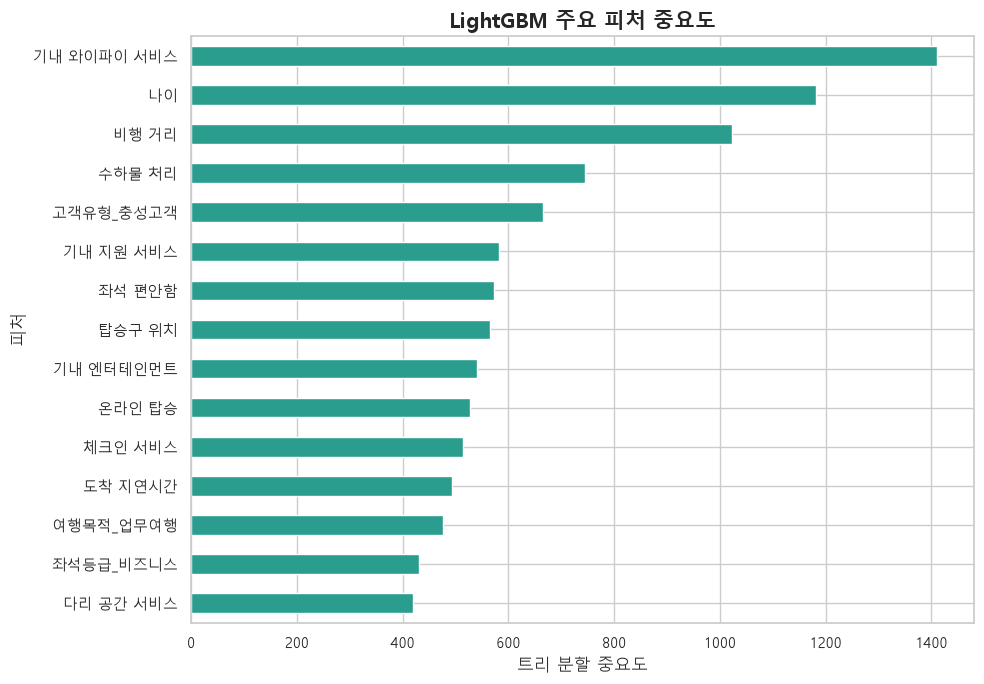

,중요도
기내 와이파이 서비스,1410
나이,1182
비행 거리,1022
수하물 처리,744
고객유형_충성고객,665
기내 지원 서비스,582
좌석 편안함,573
탑승구 위치,566
기내 엔터테인먼트,540
온라인 탑승,528


In [55]:
best_preprocessor = (
    best_lgbm
    .named_steps["preprocessor"]
)

best_model = (
    best_lgbm
    .named_steps["model"]
)

encoded_categorical_names = (
    best_preprocessor
    .named_transformers_["categorical"]
    .get_feature_names_out(
        categorical_cols
    )
)

feature_names = (
    numeric_cols
    + encoded_categorical_names.tolist()
)

feature_importance = pd.Series(
    best_model.feature_importances_,
    index=feature_names
).sort_values(
    ascending=False
)

feature_korean = {
    # 수치형 변수
    "Age": "나이",
    "Flight Distance": "비행 거리",
    "Inflight wifi service": "기내 와이파이 서비스",
    "Departure/Arrival time convenient": "출발·도착 시간 편의성",
    "Ease of Online booking": "온라인 예약 편의성",
    "Gate location": "탑승구 위치",
    "Food and drink": "음식 및 음료",
    "Online boarding": "온라인 탑승",
    "Seat comfort": "좌석 편안함",
    "Inflight entertainment": "기내 엔터테인먼트",
    "On-board service": "기내 서비스",
    "Leg room service": "다리 공간 서비스",
    "Baggage handling": "수하물 처리",
    "Checkin service": "체크인 서비스",
    "Inflight service": "기내 지원 서비스",
    "Cleanliness": "청결도",
    "Departure Delay in Minutes": "출발 지연시간",
    "Arrival Delay in Minutes": "도착 지연시간",

    # 범주형 변수의 원-핫 인코딩 결과
    "Gender_Female": "성별_여성",
    "Gender_Male": "성별_남성",
    "Customer Type_Loyal Customer": "고객유형_충성고객",
    "Customer Type_disloyal Customer": "고객유형_비충성고객",
    "Type of Travel_Business travel": "여행목적_업무여행",
    "Type of Travel_Personal Travel": "여행목적_개인여행",
    "Class_Business": "좌석등급_비즈니스",
    "Class_Eco": "좌석등급_이코노미",
    "Class_Eco Plus": "좌석등급_이코노미플러스"
}

feature_importance_korean = (
    feature_importance
    .rename(index=feature_korean)
)

top_feature_importance = (
    feature_importance_korean
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 7))

top_feature_importance.plot(
    kind="barh",
    color="#2A9D8F"
)

plt.title(
    "LightGBM 주요 피처 중요도",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("트리 분할 중요도")
plt.ylabel("피처")
plt.tight_layout()
plt.show()

display(
    feature_importance_korean
    .head(15)
    .to_frame("중요도")
)

- 피처 중요도는 LightGBM에서 해당 변수가 트리 분할에 활용된 정도를
나타낸다. 
- 중요도가 높다는 사실만으로 만족도를 증가시키거나 감소시키는 방향 또는 인과관계를 의미하지 않는다.

## K-means 기반 승객 군집 분석

In [56]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [57]:
cluster_cols = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes",
    "Inflight wifi service",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness"
]

X_cluster = train[cluster_cols].copy()

# 학습 데이터에서 구한 중앙값으로 결측치 대체
X_cluster = X_cluster.fillna(
    X_cluster.median()
)

# K-means는 거리 기반이므로 표준화가 필수
cluster_scaler = StandardScaler()

X_cluster_scaled = cluster_scaler.fit_transform(
    X_cluster
)

print("군집 분석 데이터 크기:", X_cluster_scaled.shape)
print("결측치 개수:", X_cluster.isnull().sum().sum())

군집 분석 데이터 크기: (103904, 14)
결측치 개수: 0


In [58]:
k_values = range(2, 7)

inertias = []
silhouette_scores = []

# 실루엣 점수 계산 시간을 줄이기 위한 표본
sample_size = min(10000, len(X_cluster_scaled))

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=10,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_cluster_scaled
    )

    inertias.append(
        kmeans.inertia_
    )

    silhouette_scores.append(
        silhouette_score(
            X_cluster_scaled,
            labels,
            sample_size=sample_size,
            random_state=10
        )
    )

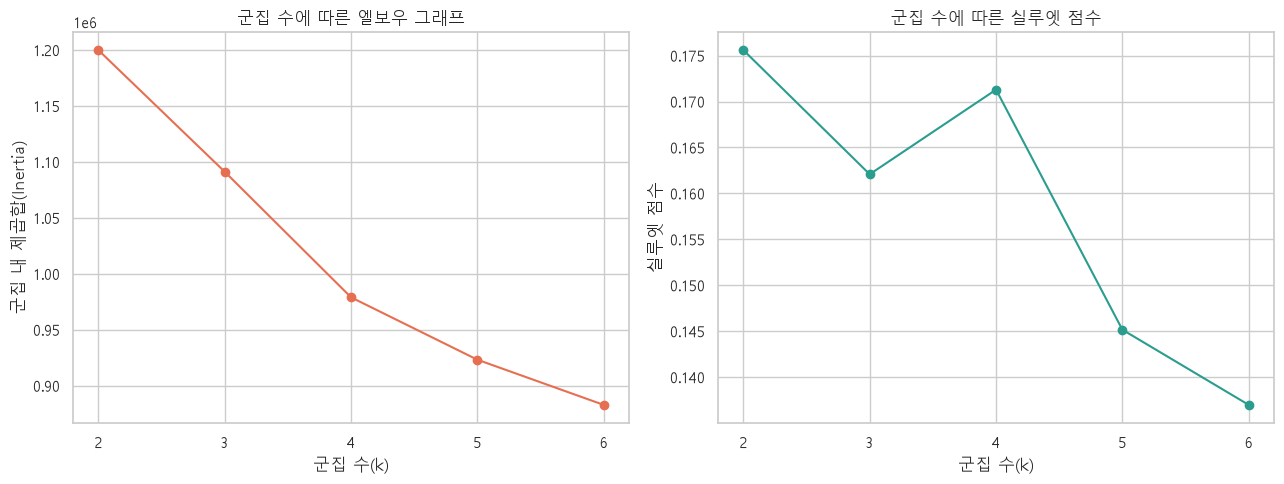

In [59]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

axes[0].plot(
    list(k_values),
    inertias,
    marker="o",
    color="#E76F51"
)

axes[0].set(
    title="군집 수에 따른 엘보우 그래프",
    xlabel="군집 수(k)",
    ylabel="군집 내 제곱합(Inertia)"
)

axes[1].plot(
    list(k_values),
    silhouette_scores,
    marker="o",
    color="#2A9D8F"
)

axes[1].set(
    title="군집 수에 따른 실루엣 점수",
    xlabel="군집 수(k)",
    ylabel="실루엣 점수"
)

axes[0].set_xticks(list(k_values))
axes[1].set_xticks(list(k_values))

plt.tight_layout()
plt.show()

In [60]:
cluster_score_df = pd.DataFrame({
    "군집 수": list(k_values),
    "Inertia": inertias,
    "실루엣 점수": silhouette_scores
})

display(
    cluster_score_df
    .round(4)
    .style
    .hide(axis="index")
)

군집 수,Inertia,실루엣 점수
2,1199911.931900,0.175600
3,1091198.685000,0.162100
4,978970.303500,0.171300
5,923218.024400,0.145200
6,882843.118000,0.137000


실루엣 점수는 k=2에서 0.1756으로 가장 높았지만, k=4의 0.1713과 차이는 0.0043으로 작았다. 또한 Inertia는 k=4까지 비교적 크게 감소하고 이후 감소 폭이 줄었다. 군집 분리도와 승객 유형의 해석 가능성을 함께 고려하여 최종 군집 수를 4개로 선택하였다. 다만 실루엣 점수가 전체적으로 낮으므로 군집 결과는 확정적인 고객 구분이 아니라 탐색적 세분화로 해석한다.

In [61]:
best_k = 4

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=10,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(
    X_cluster_scaled
)

cluster_result = train.copy()
cluster_result["군집"] = cluster_labels

In [62]:
cluster_count_df = (
    cluster_result["군집"]
    .value_counts()
    .sort_index()
    .rename("승객 수")
    .reset_index()
)

cluster_count_df.columns = [
    "군집",
    "승객 수"
]

cluster_count_df["비율(%)"] = (
    cluster_count_df["승객 수"]
    / len(cluster_result)
    * 100
)

display(
    cluster_count_df
    .round(2)
    .style
    .hide(axis="index")
)

군집,승객 수,비율(%)
0,27581,26.540000
1,43604,41.970000
2,3774,3.630000
3,28945,27.860000


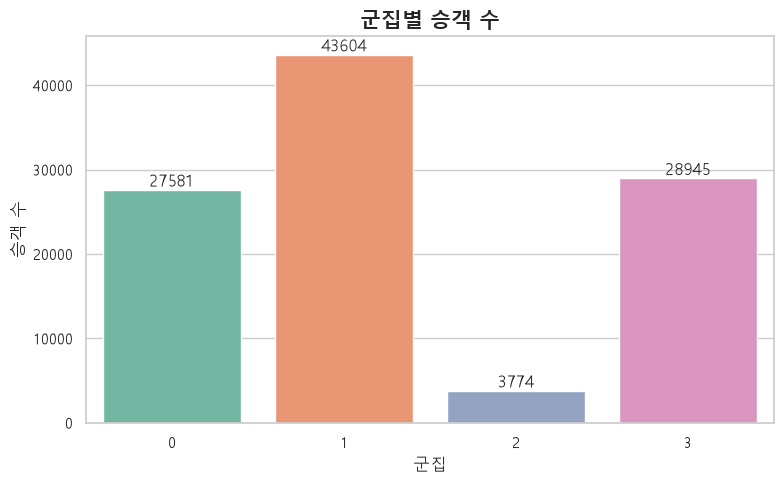

In [63]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=cluster_count_df,
    x="군집",
    y="승객 수",
    hue="군집",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d"
    )

plt.title(
    "군집별 승객 수",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("군집")
plt.ylabel("승객 수")
plt.tight_layout()
plt.show()

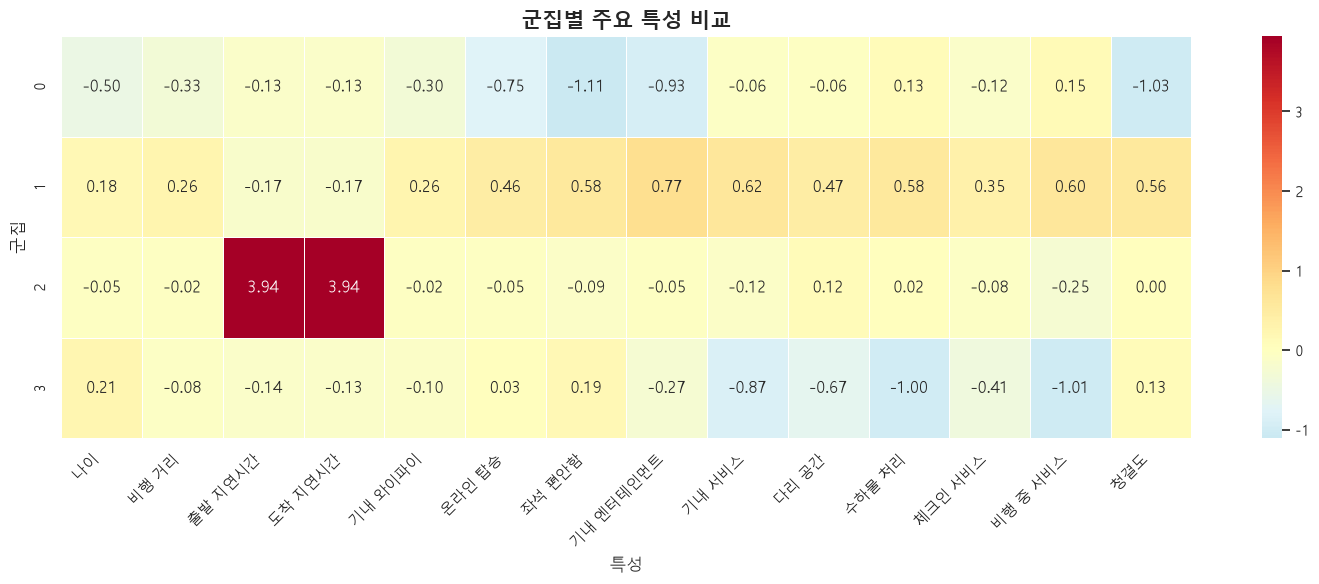

In [64]:
cluster_korean = {
    "Age": "나이",
    "Flight Distance": "비행 거리",
    "Departure Delay in Minutes": "출발 지연시간",
    "Arrival Delay in Minutes": "도착 지연시간",
    "Inflight wifi service": "기내 와이파이",
    "Online boarding": "온라인 탑승",
    "Seat comfort": "좌석 편안함",
    "Inflight entertainment": "기내 엔터테인먼트",
    "On-board service": "기내 서비스",
    "Leg room service": "다리 공간",
    "Baggage handling": "수하물 처리",
    "Checkin service": "체크인 서비스",
    "Inflight service": "비행 중 서비스",
    "Cleanliness": "청결도"
}

cluster_scaled_df = pd.DataFrame(
    X_cluster_scaled,
    columns=cluster_cols,
    index=train.index
)

cluster_scaled_df["군집"] = cluster_labels

cluster_profile_scaled = (
    cluster_scaled_df
    .groupby("군집")
    .mean()
    .rename(columns=cluster_korean)
)

plt.figure(figsize=(15, 6))

sns.heatmap(
    cluster_profile_scaled,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    center=0,
    linewidths=0.5
)

plt.title(
    "군집별 주요 특성 비교",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("특성")
plt.ylabel("군집")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

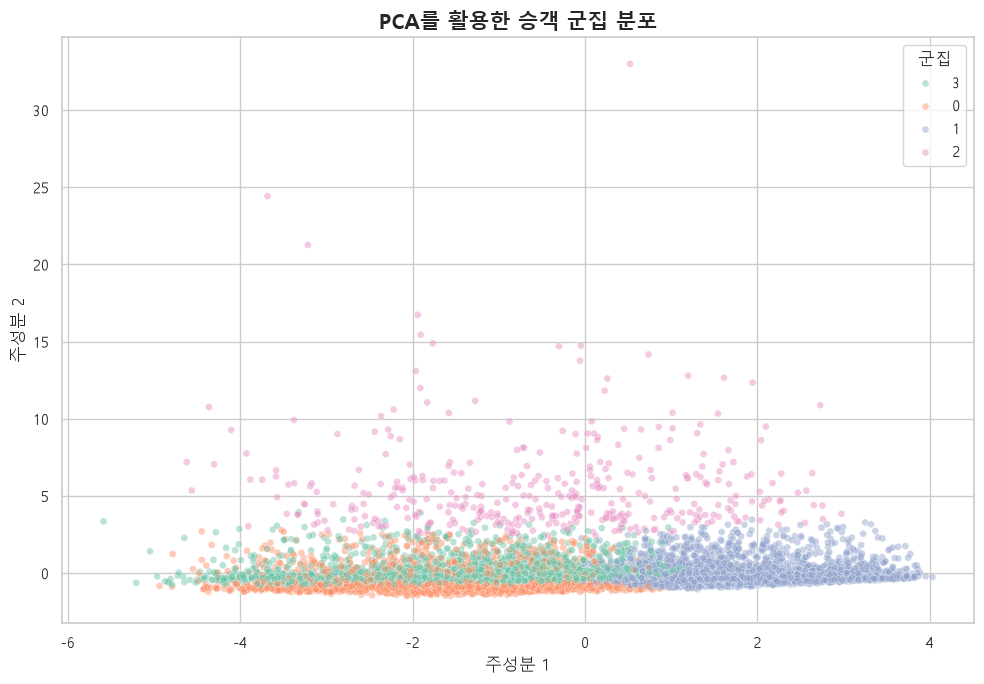

두 주성분의 설명 분산 비율: 0.3895


In [65]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=10
)

pca_result = pca.fit_transform(
    X_cluster_scaled
)

pca_df = pd.DataFrame({
    "주성분 1": pca_result[:, 0],
    "주성분 2": pca_result[:, 1],
    "군집": cluster_labels.astype(str)
})

# 시각화 속도를 위해 1만 명만 표본 추출
pca_sample = pca_df.sample(
    n=min(10000, len(pca_df)),
    random_state=10
)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_sample,
    x="주성분 1",
    y="주성분 2",
    hue="군집",
    palette="Set2",
    alpha=0.45,
    s=25
)

plt.title(
    "PCA를 활용한 승객 군집 분포",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("주성분 1")
plt.ylabel("주성분 2")
plt.legend(title="군집")
plt.tight_layout()
plt.show()

print(
    "두 주성분의 설명 분산 비율:",
    round(pca.explained_variance_ratio_.sum(), 4)
)

PCA는 군집 생성에 사용하지 않았으며, 14차원에서 생성된 군집을 2차원으로 시각화하기 위해 사용하였다. 두 주성분의 설명분산은 38.95%로 전체 정보의 일부만 표현하므로, PCA 산점도만으로 군집 품질을 판단하지 않고 실루엣 점수와 군집별 원본 평균을 함께 해석하였다.

In [66]:
cluster_result["만족 여부"] = (
    cluster_result["satisfaction"]
    .map({
        "neutral or dissatisfied": 0,
        "satisfied": 1
    })
)

cluster_satisfaction = (
    cluster_result
    .groupby("군집")
    .agg(
        승객_수=("만족 여부", "size"),
        만족_승객_수=("만족 여부", "sum"),
        만족도_비율=("만족 여부", "mean")
    )
    .reset_index()
)

cluster_satisfaction["만족도_비율"] *= 100

display(
    cluster_satisfaction
    .round(2)
    .style
    .hide(axis="index")
)

군집,승객_수,만족_승객_수,만족도_비율
0,27581,4792,17.370000
1,43604,30922,70.920000
2,3774,1330,35.240000
3,28945,7981,27.570000


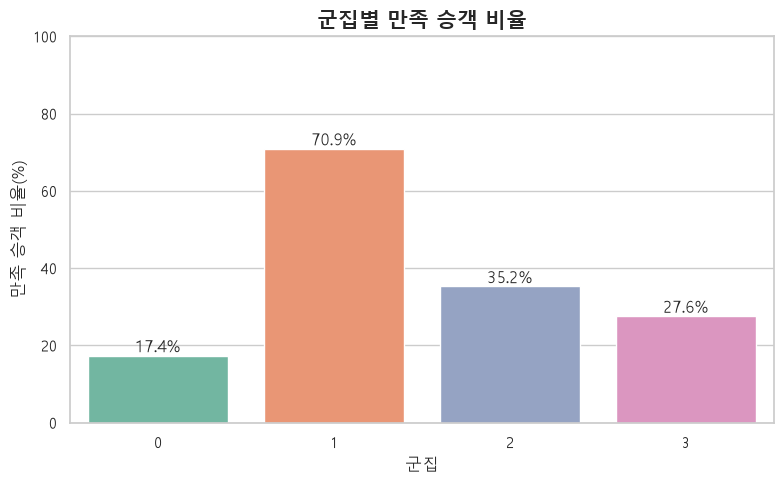

In [67]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=cluster_satisfaction,
    x="군집",
    y="만족도_비율",
    hue="군집",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.title(
    "군집별 만족 승객 비율",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("군집")
plt.ylabel("만족 승객 비율(%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [68]:
cluster_profile_original = (
    cluster_result
    .groupby("군집")[cluster_cols]
    .mean()
    .rename(columns=cluster_korean)
    .round(2)
)

display(
    cluster_profile_original
    .T
)

군집,0,1,2,3
나이,31.88,42.03,38.66,42.62
비행 거리,859.67,1451.44,1165.81,1112.09
출발 지연시간,9.81,8.45,165.34,9.55
도착 지연시간,10.29,8.48,168.03,9.99
기내 와이파이,2.33,3.08,2.70,2.59
온라인 탑승,2.23,3.87,3.18,3.30
좌석 편안함,1.98,4.21,3.32,3.69
기내 엔터테인먼트,2.12,4.39,3.29,3.00
기내 서비스,3.30,4.19,3.23,2.27
다리 공간,3.28,3.97,3.51,2.47


In [69]:
cluster_category_profile = (
    cluster_result
    .groupby("군집")
    .agg(
        충성고객_비율=(
            "Customer Type",
            lambda x: (x == "Loyal Customer").mean() * 100
        ),
        업무여행_비율=(
            "Type of Travel",
            lambda x: (x == "Business travel").mean() * 100
        ),
        비즈니스석_비율=(
            "Class",
            lambda x: (x == "Business").mean() * 100
        )
    )
    .round(2)
)

display(cluster_category_profile)

,충성고객_비율,업무여행_비율,비즈니스석_비율
군집,,,
0,68.17,56.65,27.32
1,88.29,78.05,67.49
2,80.31,69.93,44.38
3,84.96,66.88,38.09


In [70]:
cluster_summary = (
    cluster_category_profile
    .join(
        cluster_satisfaction
        .set_index("군집")[["승객_수", "만족도_비율"]]
    )
    .round(2)
)

display(
    cluster_summary
    .reset_index()
    .round(2)
    .style
    .hide(axis="index")
)

군집,충성고객_비율,업무여행_비율,비즈니스석_비율,승객_수,만족도_비율
0,68.170000,56.650000,27.320000,27581,17.370000
1,88.290000,78.050000,67.490000,43604,70.920000
2,80.310000,69.930000,44.380000,3774,35.240000
3,84.960000,66.880000,38.090000,28945,27.570000


In [71]:
cluster_names = {
    0: "단거리·객실환경 저평가형",
    1: "장거리·전반적 서비스 만족형",
    2: "극심한 지연 경험형",
    3: "운영 서비스 저평가형"
}

cluster_result["군집 유형"] = (
    cluster_result["군집"]
    .map(cluster_names)
)

cluster_named_summary = (
    cluster_result
    .groupby(["군집", "군집 유형"])
    .agg(
        승객_수=("만족 여부", "size"),
        만족도_비율=("만족 여부", "mean")
    )
    .reset_index()
)

cluster_named_summary["만족도_비율"] *= 100

display(
    cluster_named_summary
    .round(2)
    .style
    .hide(axis="index")
)

군집,군집 유형,승객_수,만족도_비율
0,단거리·객실환경 저평가형,27581,17.370000
1,장거리·전반적 서비스 만족형,43604,70.920000
2,극심한 지연 경험형,3774,35.240000
3,운영 서비스 저평가형,28945,27.570000


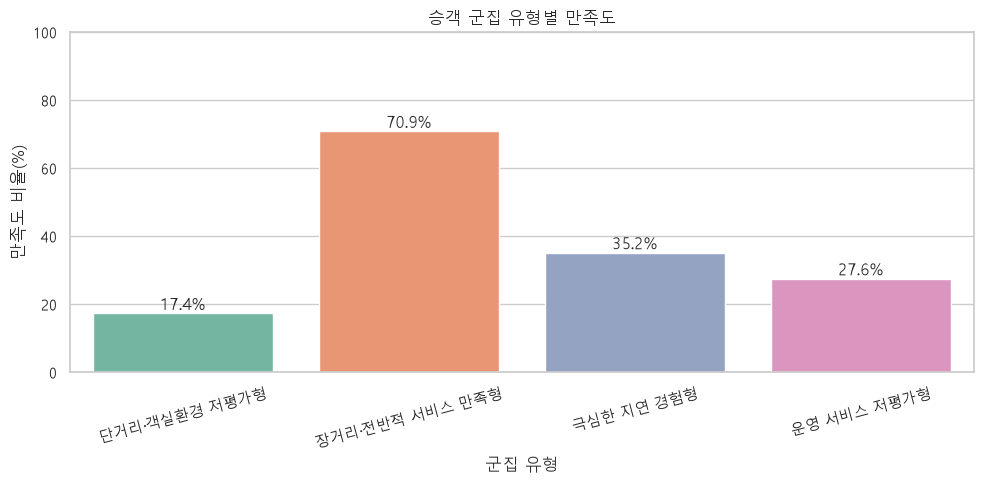

In [72]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=cluster_named_summary,
    x="군집 유형",
    y="만족도_비율",
    hue="군집 유형",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.title("승객 군집 유형별 만족도")
plt.xlabel("군집 유형")
plt.ylabel("만족도 비율(%)")
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 군집별 해석

- 군집 0은 짧은 거리의 이용객이 많으며 좌석 편안함, 기내 엔터테인먼트, 청결도 평가가 낮았다. 만족도는 17.37%로 가장 낮아 객실 환경 개선이 필요한 집단이다.
- 군집 1은 장거리·업무여행·비즈니스석 승객 비율이 높고 대부분의 서비스를 높게 평가했다. 만족도 역시 70.92%로 가장 높은 핵심 고객 집단이다.
- 군집 2는 출발과 도착이 평균 약 165~168분 지연된 소수 집단이다. 지연 안내와 보상 등 비정상 운항 대응이 중요한 집단이다.
- 군집 3은 충성고객 비율이 높지만 기내 서비스, 수하물 처리, 비행 중 서비스 평가가 낮고 만족도도 27.57%에 그쳤다. 운영 서비스 품질 개선이 필요한 집단이다.

In [73]:
stability_results = []

for seed in [10, 20, 30, 40, 50]:
    stability_model = KMeans(
        n_clusters=4,
        random_state=seed,
        n_init=10
    )

    stability_labels = stability_model.fit_predict(
        X_cluster_scaled
    )

    stability_score = silhouette_score(
        X_cluster_scaled,
        stability_labels,
        sample_size=10000,
        random_state=10
    )

    stability_results.append({
        "초기값": seed,
        "실루엣 점수": stability_score,
        "Inertia": stability_model.inertia_
    })

stability_df = pd.DataFrame(stability_results)

display(
    stability_df
    .round(4)
    .style
    .hide(axis="index")
)

초기값,실루엣 점수,Inertia
10,0.171300,978970.303500
20,0.171300,978970.350000
30,0.171300,978970.472300
40,0.171300,978970.492900
50,0.171300,978970.417400


### 군집 안정성 검증

K-means는 초기 중심점에 따라 결과가 달라질 수 있으므로, random_state를 10, 20, 30, 40, 50으로 변경하여 안정성을 확인하였다. 모든 조건에서 실루엣 점수는 0.1713으로 동일했고, Inertia도 약 978,970 수준에서 매우 작은 차이만 나타났다. 따라서 선택한 4개 군집 결과가 초기값에 크게 의존하지 않는다는 것을 확인하였다.

## 종합 결론

- Logistic Regression, Decision Tree, Random Forest, XGBoost,
  LightGBM을 비교하고 Stratified 5-Fold 교차검증을 수행한 결과,
  LightGBM을 최종 분류 모델로 선정하였다.

- 실제 불만족 고객을 만족으로 오판하여 관리 대상에서 놓치는 FP를
  중요한 오류로 정의하고, validation 데이터에서 만족 판정 임계값을
  조정하였다.

- Precision 0.99 이상, Recall 0.91 이상, F1-score 0.95 이상을
  유지하는 범위에서 FP가 가장 적은 임계값 0.75를 최종 분류
  임계값으로 선택하였다.

- 임계값 0.75와 0.81의 비용 손익분기 분석 결과, FP의 단위 비용이 
  FN의 5.375배를 초과하면 0.81이 유리하고,
  그 미만이면 0.75가 유리하며, 정확히 5.375배이면 두 임계값의
  총비용이 동일한 것으로 나타났다. 실제 비용자료가 없으므로 본 프로젝트에서는
  FP 감소와 전체 성능의 균형이 좋은 0.75를 선택하였다.

- 확정된 임계값 0.75를 독립 test 데이터에 적용한 결과 Accuracy
  0.9592, Precision 0.9945, Recall 0.9122, F1-score 0.9516으로
  나타났다.

- 최종 혼동행렬은 TN 14,515명, FP 58명, FN 1,001명, TP
  10,402명이었으며 FPR은 0.0040으로 나타났다. 기본 임계값
  0.5보다 FP는 감소했지만 FN은 증가하여 Precision과 Recall 사이의
  상충관계를 확인하였다.

- LightGBM 피처 중요도 분석 결과 기내 와이파이, 나이, 비행 거리,
  수하물 처리 등이 예측에 많이 활용된 것으로 나타났다. 다만 피처
  중요도는 인과관계나 영향 방향을 의미하지 않는다.

- K-means 분석에서는 승객을 4개의 탐색적 유형으로 구분하고,
  군집별 서비스 평가와 만족도 차이를 바탕으로 맞춤 개선 방향을
  제시하였다. 다만 실루엣 점수가 약 0.17로 높지 않아 군집 결과는
  확정적인 고객 구분이 아닌 탐색적 세분화로 해석하였다.

## 한계 및 향후 개선 방향

- 군집 분석의 실루엣 점수가 약 0.17로 군집 간 분리가 강하지 않았다.

- 설문 점수만으로는 승객의 구체적인 불만 원인을 완전히 설명하기 어렵다.

- 항공사, 노선, 항공권 가격 등의 추가 변수가 있다면 예측과 군집 해석을 개선할 수 있다.

- 추후 SHAP 분석을 통해 개별 변수의 영향 방향을 더욱 구체적으로 확인할 수 있다.

- 본 데이터에는 고객 이탈 손실, 고객 생애가치, 상담·쿠폰 비용과 같은
  실제 비용 정보가 포함되어 있지 않다. 따라서 계산된 5.375배는 실제
  항공사의 FP·FN 비용비율이 아니라 임계값 0.75와 0.81의 총비용이
  같아지는 이론적 손익분기점이다. 실제 운영에서는 항공사의 고객
  이탈률과 서비스 회복 비용을 반영하여 임계값을 다시 결정해야 한다.